# **ADVANCED EXPERIMENTS & BONUS MODELS: REGRESSION**

## **1. Import Libraries**

In [1]:
import importlib
import models
import visualizations
importlib.reload(models)
importlib.reload(visualizations)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import tracemalloc as _tmal
import math
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import KFold

# Models — class-based API
from models import (
    BasisExpansion,
    LinearRegression,
    FeatureSelector,
    RobustRegression,
    KernelRegression,
    BayesianLinearRegression,
    BaseEvaluator,
    ModelEvaluator,
)

from visualizations import plot_lml_history, plot_gp_posterior_predictive

# Display configuration
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("All libraries imported successfully.")

All libraries imported successfully.


## **2. Load Data for Model**

In [2]:
data_dir = '../../data/processed/'

train_df = pd.read_csv(data_dir + 'Energy_Use_train.csv', engine='python')
val_df = pd.read_csv(data_dir + 'Energy_Use_val.csv', engine='python')
test_df = pd.read_csv(data_dir + 'Energy_Use_test.csv', engine='python')

target_col = 'Appliances'

_perf_records = {}  # {model_name: {'time_s': float, 'memory_mb': float}}

# Split X and y
y_train_raw = train_df[target_col]
X_train_raw = train_df.drop(columns=[target_col])

y_val_raw = val_df[target_col]
X_val_raw = val_df.drop(columns=[target_col])

y_test_raw = test_df[target_col]
X_test_raw = test_df.drop(columns=[target_col])

# Convert format and add bias
y_train = y_train_raw.values
y_val = y_val_raw.values
y_test = y_test_raw.values

# Add a column of all ones (Bias) at the beginning of the feature matrix X to create Phi
Phi_train = LinearRegression.add_bias(X_train_raw.values)
Phi_val   = LinearRegression.add_bias(X_val_raw.values)
Phi_test  = LinearRegression.add_bias(X_test_raw.values)

# Get the list of feature names to print results (Column 0 is Bias)
feature_names = ['Bias (w0)'] + list(X_train_raw.columns)

print(f"Training set dimensions   : Phi = {Phi_train.shape}, y = {y_train.shape}")
print(f"Validation set dimensions : Phi = {Phi_val.shape}, y = {y_val.shape}")
print(f"Test set dimensions       : Phi = {Phi_test.shape}, y = {y_test.shape}")

Training set dimensions   : Phi = (13813, 40), y = (13813,)
Validation set dimensions : Phi = (2961, 40), y = (2961,)
Test set dimensions       : Phi = (2961, 40), y = (2961,)


## **3. Bayesian Linear Regression & Uncertainty Quantification**

### **3.1. Implementation**

**Hồi quy Bayesian** là một phương pháp xác suất hoàn chỉnh để ước lượng tham số mô hình. Khác với Maximum Likelihood chỉ tìm một giá trị điểm duy nhất cho vector trọng số $\mathbf{w}$, Bayesian Linear Regression tính toán **phân phối hậu nghiệm (posterior distribution)** $p(\mathbf{w}|\mathbf{t})$ của trọng số dựa trên dữ liệu quan sát.

#### **A. Mô hình Xác suất**

**1. Likelihood (Hàm hợp lý):**

Giả định nhiễu tuân theo phân phối Gaussian với độ chính xác $\beta = 1/\sigma_n^2$:

$$p(\mathbf{t}|\mathbf{w}, \beta) = \prod_{n=1}^{N} \mathcal{N}(t_n | \mathbf{w}^T \phi(\mathbf{x}_n), \beta^{-1})$$

Trong đó:
- $t_n$: Giá trị mục tiêu thực tế của mẫu thứ $n$
- $\phi(\mathbf{x}_n)$: Vector đặc trưng sau khi biến đổi phi tuyến (RBF basis)
- $\beta^{-1} = \sigma_n^2$: Phương sai của nhiễu

**2. Prior (Phân phối Tiên nghiệm):**

Đặt prior Gaussian đẳng hướng (isotropic) trên $\mathbf{w}$ với độ chính xác $\alpha$:

$$p(\mathbf{w}|\alpha) = \mathcal{N}(\mathbf{w}|\mathbf{0}, \alpha^{-1}\mathbf{I})$$

Ý nghĩa:
- Prior này thể hiện niềm tin ban đầu rằng các trọng số nên gần với 0
- Tham số $\alpha$ đóng vai trò như **hệ số regularization** trong Ridge Regression
- $\alpha$ càng lớn -> prior càng mạnh -> trọng số bị ép về 0 nhiều hơn

**3. Posterior (Phân phối Hậu nghiệm):**

Theo định lý Bayes:

$$p(\mathbf{w}|\mathbf{t}, \alpha, \beta) = \frac{p(\mathbf{t}|\mathbf{w}, \beta) p(\mathbf{w}|\alpha)}{p(\mathbf{t}|\alpha, \beta)}$$

Do cả likelihood và prior đều là Gaussian, posterior cũng là Gaussian (tính chất **conjugate**):

$$p(\mathbf{w}|\mathbf{t}) = \mathcal{N}(\mathbf{w}|\mathbf{m}_N, \mathbf{S}_N)$$

Với:
- **Posterior covariance (Ma trận hiệp phương sai hậu nghiệm):** 
  $$\mathbf{S}_N = (\alpha \mathbf{I} + \beta \mathbf{\Phi}^T \mathbf{\Phi})^{-1}$$
  
- **Posterior mean (Trung bình hậu nghiệm):** 
  $$\mathbf{m}_N = \beta \mathbf{S}_N \mathbf{\Phi}^T \mathbf{t}$$

**Ý nghĩa:**
- $\mathbf{m}_N$ là ước lượng tốt nhất của trọng số dựa trên dữ liệu
- $\mathbf{S}_N$ định lượng độ bất định về trọng số

#### **B. Phân phối Dự đoán (Predictive Distribution)**

Để dự đoán cho điểm mới $\mathbf{x}^*$, ta tích phân trên toàn bộ không gian tham số:

$$p(t^*|\mathbf{x}^*, \mathbf{t}) = \int p(t^*|\mathbf{x}^*, \mathbf{w}) p(\mathbf{w}|\mathbf{t}) d\mathbf{w}$$

Kết quả là một phân phối Gaussian:

$$p(t^*|\mathbf{x}^*, \mathbf{t}) = \mathcal{N}(t^* | \bar{f}^*, \sigma_N^2(\mathbf{x}^*))$$

Với:
- **Predictive mean (Giá trị dự đoán trung bình):** 
  $$\bar{f}^* = \mathbf{m}_N^T \phi(\mathbf{x}^*)$$
  
- **Predictive variance (Phương sai dự đoán):** 
  $$\sigma_N^2(\mathbf{x}^*) = \frac{1}{\beta} + \phi(\mathbf{x}^*)^T \mathbf{S}_N \phi(\mathbf{x}^*)$$

**Phân tích hai thành phần của phương sai dự đoán:**

1. **Aleatoric Uncertainty (Độ bất định ngẫu nhiên):** $1/\beta = \sigma_n^2$
   - Độ bất định do nhiễu cố hữu trong dữ liệu
   - **Không thể giảm** dù có thêm bao nhiêu dữ liệu huấn luyện
   - Phản ánh tính ngẫu nhiên tự nhiên của hệ thống

2. **Epistemic Uncertainty (Độ bất định nhận thức):** $\phi(\mathbf{x}^*)^T \mathbf{S}_N \phi(\mathbf{x}^*)$
   - Độ bất định do thiếu dữ liệu hoặc thiếu kiến thức về mô hình
   - **Có thể giảm** khi thu thập thêm dữ liệu huấn luyện
   - Lớn ở vùng ngoại suy (xa dữ liệu huấn luyện), nhỏ ở vùng nội suy

#### **C. Ý nghĩa của Vùng Bất định $\bar{f}^* \pm 2\sigma_N$**

Khoảng tin cậy 95% (xấp xỉ $\pm 2\sigma_N$) cho biết:

- **Vùng bất định hẹp:** 
  - Mô hình tự tin về dự đoán
  - Có nhiều dữ liệu huấn luyện gần điểm test
  - Epistemic uncertainty thấp
  
- **Vùng bất định rộng:** 
  - Mô hình không chắc chắn
  - Ít dữ liệu huấn luyện hoặc đang ngoại suy xa
  - Epistemic uncertainty cao

**Ưu điểm lớn của Bayesian so với Maximum Likelihood:**
- Không chỉ cho dự đoán điểm mà còn định lượng được độ tin cậy
- Giúp ra quyết định tốt hơn trong các ứng dụng quan trọng
- Cho biết khi nào cần thu thập thêm dữ liệu

### **3.1. Data Preparation & RBF Basis Functions**

Chúng ta sẽ sử dụng các hàm cơ sở RBF (Radial Basis Function) để biến đổi các đặc trưng đầu vào lên không gian có số chiều cao hơn. Điều này cho phép mô hình Bayesian nắm bắt được các mối quan hệ phi tuyến trong dữ liệu.

In [3]:
_tmal.start(); _t0 = time.time()
print("BAYESIAN LINEAR REGRESSION WITH RBF BASIS FUNCTIONS")

# Select a single feature for visualization (e.g., T_out - outdoor temperature)
feature_idx = list(X_train_raw.columns).index('T_out')
x_train_1d = X_train_raw.values[:, feature_idx]
x_test_1d = X_test_raw.values[:, feature_idx]

print(f"\nSelected feature for 1D visualization: {X_train_raw.columns[feature_idx]}")
print(f"Training samples: {len(x_train_1d)}")
print(f"Test samples: {len(x_test_1d)}")

# Create RBF basis functions
# Place M=15 centers uniformly across the range of training data
M = 15
centers = np.linspace(x_train_1d.min(), x_train_1d.max(), M)
s = 0.3  # Bandwidth parameter for RBF

print(f"\nRBF Configuration:")
print(f"  - Number of basis functions (M): {M}")
print(f"  - Bandwidth (s): {s}")
print(f"  - Centers range: [{centers.min():.4f}, {centers.max():.4f}]")

# Compute design matrices Phi for train and test
Phi_train_rbf = BayesianLinearRegression.gaussian_rbf(x_train_1d, centers, s)
Phi_test_rbf  = BayesianLinearRegression.gaussian_rbf(x_test_1d,  centers, s)

print(f"\nDesign Matrix Shapes:")
print(f"  - Phi_train: {Phi_train_rbf.shape}")
print(f"  - Phi_test: {Phi_test_rbf.shape}")

BAYESIAN LINEAR REGRESSION WITH RBF BASIS FUNCTIONS

Selected feature for 1D visualization: T_out
Training samples: 13813
Test samples: 2961

RBF Configuration:
  - Number of basis functions (M): 15
  - Bandwidth (s): 0.3
  - Centers range: [-2.5831, 3.3701]

Design Matrix Shapes:
  - Phi_train: (13813, 15)
  - Phi_test: (2961, 15)


**Nhận xét về cấu hình RBF:**

1. **Feature visualization (T_out):** Lựa chọn tốt vì nhiệt độ ngoài trời có mối quan hệ phi tuyến rõ ràng với tiêu thụ điện, dễ trực quan hóa và giải thích.

2. **Số lượng basis functions (M = 15):** Cân bằng tối ưu - đủ linh hoạt để nắm bắt quan hệ phi tuyến mà không quá phức tạp gây overfitting. Tỷ lệ mẫu/tham số = 13,813/15 ≈ 921:1 rất tốt.

3. **Bandwidth (s = 0.3):** Giá trị vừa phải cho phép các RBF có overlap hợp lý (≈1.4x khoảng cách giữa centers), đảm bảo tính liên tục của hàm dự đoán mà không bị overfitting.

4. **Phạm vi centers [-2.58, 3.37]:** Phủ đầy đủ phạm vi dữ liệu huấn luyện, tránh vùng "chết" không được bao phủ. Điều này quan trọng để mô hình Bayesian có thể định lượng chính xác epistemic uncertainty.

5. **Design matrix (13,813 × 15):** Kích thước vừa phải, chi phí tính toán posterior thấp ($O(15^3)$ = 3,375 operations), phù hợp cho ứng dụng thực tế.

**Kỳ vọng:** Với cấu hình này, mô hình sẽ nắm bắt tốt quan hệ phi tuyến và cho uncertainty bands hợp lý, trong đó aleatoric uncertainty (nhiễu cố hữu) sẽ chiếm ưu thế do bản chất ngẫu nhiên của hành vi người dùng.


### **3.2. Compute Posterior Distribution**

Chúng ta tính phân phối hậu nghiệm $p(\mathbf{w}|\mathbf{t}) = \mathcal{N}(\mathbf{w}|\mathbf{m}_N, \mathbf{S}_N)$ bằng các công thức:

* **Ma trận hiệp phương sai hậu nghiệm (Posterior covariance):** 
  $$\mathbf{S}_N = (\alpha \mathbf{I} + \beta \mathbf{\Phi}^T \mathbf{\Phi})^{-1}$$

* **Trung bình hậu nghiệm (Posterior mean):** 
  $$\mathbf{m}_N = \beta \mathbf{S}_N \mathbf{\Phi}^T \mathbf{t}$$

Trong đó:
* $\alpha$: Kiểm soát độ chính xác của prior (cường độ regularization)
* $\beta = 1/\sigma_n^2$: Độ chính xác của nhiễu (noise precision)

In [4]:
# Set hyperparameters
alpha = 1.0   # Prior precision (regularization)
sigma_n = 50.0  # Noise standard deviation
beta = 1.0 / (sigma_n ** 2)  # Noise precision
print("COMPUTING POSTERIOR DISTRIBUTION")
print(f"\nHyperparameters:")
print(f"  - Alpha (prior precision): {alpha}")
print(f"  - Sigma_n (noise std): {sigma_n}")
print(f"  - Beta (noise precision): {beta:.6f}")

# Compute posterior mean m_N and covariance S_N
_tmal.start(); _t0 = time.time()
m_N, S_N = BayesianLinearRegression.compute_posterior(Phi_train_rbf, y_train, alpha, beta)
_perf_records['Bayesian LR - Posterior (1D RBF)'] = {'time_s': time.time()-_t0, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

print(f"\nPosterior Statistics:")
print(f"  - Posterior mean (m_N) shape: {m_N.shape}")
print(f"  - Posterior covariance (S_N) shape: {S_N.shape}")
print(f"  - Mean of m_N: {np.mean(m_N):.4f}")
print(f"  - Std of m_N: {np.std(m_N):.4f}")
print(f"  - Trace of S_N: {np.trace(S_N):.4f}")

COMPUTING POSTERIOR DISTRIBUTION

Hyperparameters:
  - Alpha (prior precision): 1.0
  - Sigma_n (noise std): 50.0
  - Beta (noise precision): 0.000400

Posterior Statistics:
  - Posterior mean (m_N) shape: (15,)
  - Posterior covariance (S_N) shape: (15, 15)
  - Mean of m_N: 23.4281
  - Std of m_N: 14.9836
  - Trace of S_N: 11.7704


**Nhận xét về Posterior Distribution:**

1. **Hyperparameters:**
   - **α = 1.0:** Prior precision thấp -> regularization nhẹ, cho phép mô hình linh hoạt học từ dữ liệu
   - **σₙ = 50.0:** Độ lệch chuẩn nhiễu lớn, phản ánh đúng bản chất nhiễu cao của dữ liệu tiêu thụ điện
   - **β = 0.0004:** Noise precision thấp tương ứng với σₙ² = 2500, thể hiện aleatoric uncertainty cao

2. **Posterior mean (m_N):**
   - Shape (15,): Tương ứng với 15 trọng số cho 15 RBF basis functions
   - Mean = 23.43, Std = 14.98: Các trọng số có độ lớn và biến thiên đáng kể, cho thấy mỗi RBF đóng góp khác nhau vào dự đoán
   - Không có trọng số nào quá lớn -> mô hình cân bằng, không bị overfitting

3. **Posterior covariance (S_N):**
   - Shape (15, 15): Ma trận đầy đủ mô tả độ bất định và tương quan giữa các trọng số
   - Trace(S_N) = 11.77: Tổng phương sai của tất cả trọng số, phản ánh epistemic uncertainty
   - Giá trị trace tương đối nhỏ so với σₙ² = 2500 -> epistemic uncertainty << aleatoric uncertainty

**Kết luận:** Posterior distribution cho thấy mô hình đã học được các trọng số hợp lý với độ bất định thấp (nhờ tập train lớn), trong khi aleatoric uncertainty chiếm ưu thế do bản chất ngẫu nhiên của dữ liệu.


### **3.3. Compute Predictive Distribution**
Với mỗi điểm test, chúng ta tính phân phối dự đoán:

$$p(t^*|\mathbf{x}^*, \mathbf{t}) = \mathcal{N}(t^* | \bar{f}^*, \sigma_N^2(\mathbf{x}^*))$$

Trong đó:
* **Giá trị dự đoán trung bình (Predictive mean):** 
  $$\bar{f}^* = \mathbf{m}_N^T \phi(\mathbf{x}^*)$$

* **Độ lệch chuẩn dự đoán (Predictive std):** 
  $$\sigma_N(\mathbf{x}^*) = \sqrt{\frac{1}{\beta} + \phi(\mathbf{x}^*)^T \mathbf{S}_N \phi(\mathbf{x}^*)}$$

Phương sai dự đoán bao gồm hai thành phần:

1. **Aleatoric uncertainty (Độ bất định ngẫu nhiên)** ($1/\beta$): Nhiễu cố hữu không thể giảm
2. **Epistemic uncertainty (Độ bất định nhận thức)** ($\phi(\mathbf{x}^*)^T \mathbf{S}_N \phi(\mathbf{x}^*)$): Độ bất định của mô hình


In [5]:
print("COMPUTING PREDICTIVE DISTRIBUTION ON TEST SET")

# Compute predictive mean and standard deviation
_tmal.start(); _t0 = time.time()
f_star, sigma_N = BayesianLinearRegression.compute_predictive_distribution(Phi_test_rbf, m_N, S_N, beta)
_perf_records['Bayesian LR - Predictive (1D RBF)'] = {'time_s': time.time()-_t0, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

print(f"\nPredictive Distribution Statistics:")
print(f"  - Predictive mean (f_star) shape: {f_star.shape}")
print(f"  - Predictive std (sigma_N) shape: {sigma_N.shape}")
print(f"  - Mean prediction: {np.mean(f_star):.4f}")
print(f"  - Mean uncertainty: {np.mean(sigma_N):.4f}")
print(f"  - Min uncertainty: {np.min(sigma_N):.4f}")
print(f"  - Max uncertainty: {np.max(sigma_N):.4f}")

COMPUTING PREDICTIVE DISTRIBUTION ON TEST SET

Predictive Distribution Statistics:
  - Predictive mean (f_star) shape: (2961,)
  - Predictive std (sigma_N) shape: (2961,)
  - Mean prediction: 34.4539
  - Mean uncertainty: 50.0078
  - Min uncertainty: 50.0000
  - Max uncertainty: 50.0122


**Nhận xét về Predictive Distribution:**

1. **Kích thước output:**
   - f_star và sigma_N đều có shape (2961,): Mỗi điểm test có một dự đoán và một độ bất định riêng
   - Đúng với số lượng mẫu test, đảm bảo tính toán chính xác

2. **Giá trị dự đoán trung bình:**
   - Mean prediction = 34.45 Wh: Nằm trong phạm vi hợp lý của tiêu thụ điện gia dụng
   - Phản ánh xu hướng chung của dữ liệu test

3. **Phân tích độ bất định (Uncertainty):**
   - **Mean uncertainty = 50.01 ≈ σₙ = 50.0:** Gần như bằng noise std đã đặt
   - **Min = 50.00, Max = 50.01:** Biến thiên cực kỳ nhỏ (chỉ 0.01)
   - **Ý nghĩa quan trọng:** Độ bất định gần như không đổi trên toàn bộ test set

4. **Phân tích hai thành phần bất định:**
   - **Aleatoric uncertainty:** $1/\beta = \sigma_n^2 = 2500$ → $\sqrt{2500} = 50.0$
   - **Epistemic uncertainty:** $\sqrt{\phi^T \mathbf{S}_N \phi} \approx 0.01$ (rất nhỏ)
   - **Tỷ lệ:** Aleatoric chiếm ~99.98%, Epistemic chỉ ~0.02%

5. **Kết luận:**
   - **Aleatoric uncertainty chiếm ưu thế tuyệt đối:** Do bản chất ngẫu nhiên cao của hành vi tiêu thụ điện
   - **Epistemic uncertainty cực thấp:** Nhờ tập train lớn (13,813 mẫu) và RBF phủ đều phạm vi dữ liệu
   - **Độ bất định đồng đều:** Mô hình tự tin như nhau trên toàn bộ test set, không có vùng ngoại suy
   - **Hạn chế cải thiện:** Thu thập thêm dữ liệu sẽ không giảm được độ bất định (vì aleatoric không thể giảm)


### **3.4. Model Evaluation**

So sánh Bayesian Linear Regression với Ridge Regression chuẩn trên tập test.

In [6]:
bayesian_metrics = LinearRegression.metrics(y_test, f_star)
bayesian_mse     = LinearRegression.mse(y_test, f_star)

# Train Ridge Regression for comparison
_tmal.start(); _t0 = time.time()
w_ridge      = LinearRegression.fit_ridge(Phi_train_rbf, y_train, lam=alpha/beta, bias_is_first=False)
_perf_records['Ridge Regression (vs Bayesian, 1D)'] = {'time_s': time.time()-_t0, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()
pred_ridge   = Phi_test_rbf @ w_ridge
ridge_metrics = LinearRegression.metrics(y_test, pred_ridge)
ridge_mse     = LinearRegression.mse(y_test, pred_ridge)

print("MODEL COMPARISON: BAYESIAN vs RIDGE REGRESSION")
print("=" * 90)
print(f"{'Model':<30} | {'MSE':<12} | {'RMSE':<12} | {'MAE':<12} | {'R²':<12}")
print("-" * 90)
print(f"{'Bayesian Linear Regression':<30} | {bayesian_mse:<12.4f} | {bayesian_metrics['RMSE']:<12.4f} | {bayesian_metrics['MAE']:<12.4f} | {bayesian_metrics['R2']:<12.4f}")
print(f"{'Ridge Regression (Baseline)':<30} | {ridge_mse:<12.4f} | {ridge_metrics['RMSE']:<12.4f} | {ridge_metrics['MAE']:<12.4f} | {ridge_metrics['R2']:<12.4f}")

MODEL COMPARISON: BAYESIAN vs RIDGE REGRESSION
Model                          | MSE          | RMSE         | MAE          | R²          
------------------------------------------------------------------------------------------
Bayesian Linear Regression     | 13946.6005   | 118.0957     | 68.2741      | -0.6889     
Ridge Regression (Baseline)    | 13946.6005   | 118.0957     | 68.2741      | -0.6889     


**Nhận xét:**

1. **Độ chính xác hoàn toàn giống nhau:**
   - MSE, RMSE, MAE, R² của cả hai mô hình **giống hệt nhau** đến từng chữ số thập phân
   - Điều này là **hoàn toàn đúng lý thuyết** vì:
     - Bayesian LR với prior Gaussian tương đương toán học với Ridge Regression
     - Posterior mean $\mathbf{m}_N$ chính là nghiệm MAP (Maximum A Posteriori)
     - Khi $\lambda = \alpha/\beta = 1.0/0.0004 = 2500$, hai phương pháp cho cùng một nghiệm

2. **Phân tích hiệu năng:**
   - **R² = -0.69 (âm):** Mô hình dự đoán tệ hơn cả việc dùng giá trị trung bình
   - **Nguyên nhân:** Chỉ dùng 1 feature (T_out) với 15 RBF không đủ để giải thích biến động phức tạp của tiêu thụ điện
   - **Lưu ý:** Đây là visualization 1D để minh họa uncertainty, không phải mô hình thực tế

3. **Giá trị gia tăng của Bayesian:**
   - **Không phải về độ chính xác** (vì giống Ridge)
   - **Mà là về uncertainty quantification:**
     - Bayesian cung cấp $\sigma_N$ cho mỗi dự đoán
     - Ridge chỉ cho một giá trị điểm, không có thông tin về độ tin cậy
     - Bayesian cho biết: "Dự đoán này có độ bất định ±100 Wh (±2σ)"

4. **Kết luận:**
   - Về mặt dự đoán điểm: Bayesian = Ridge (như lý thuyết)
   - Về mặt thông tin: Bayesian >> Ridge (có uncertainty quantification)
   - Trong thực tế: Nên dùng tất cả 39 features để có R² dương


### **3.5. Visualization: Predictive Mean & Uncertainty Bands**
Chúng ta trực quan hóa giá trị dự đoán trung bình $\bar{f}^*$ cùng với khoảng tin cậy 95% $\bar{f}^* \pm 2\sigma_N$.

**Cách diễn giải:**
* **Vùng bất định hẹp**: Mô hình tự tin về dự đoán (có đủ dữ liệu huấn luyện gần đó)
* **Vùng bất định rộng**: Mô hình không chắc chắn (dữ liệu huấn luyện thưa thớt hoặc đang ngoại suy)


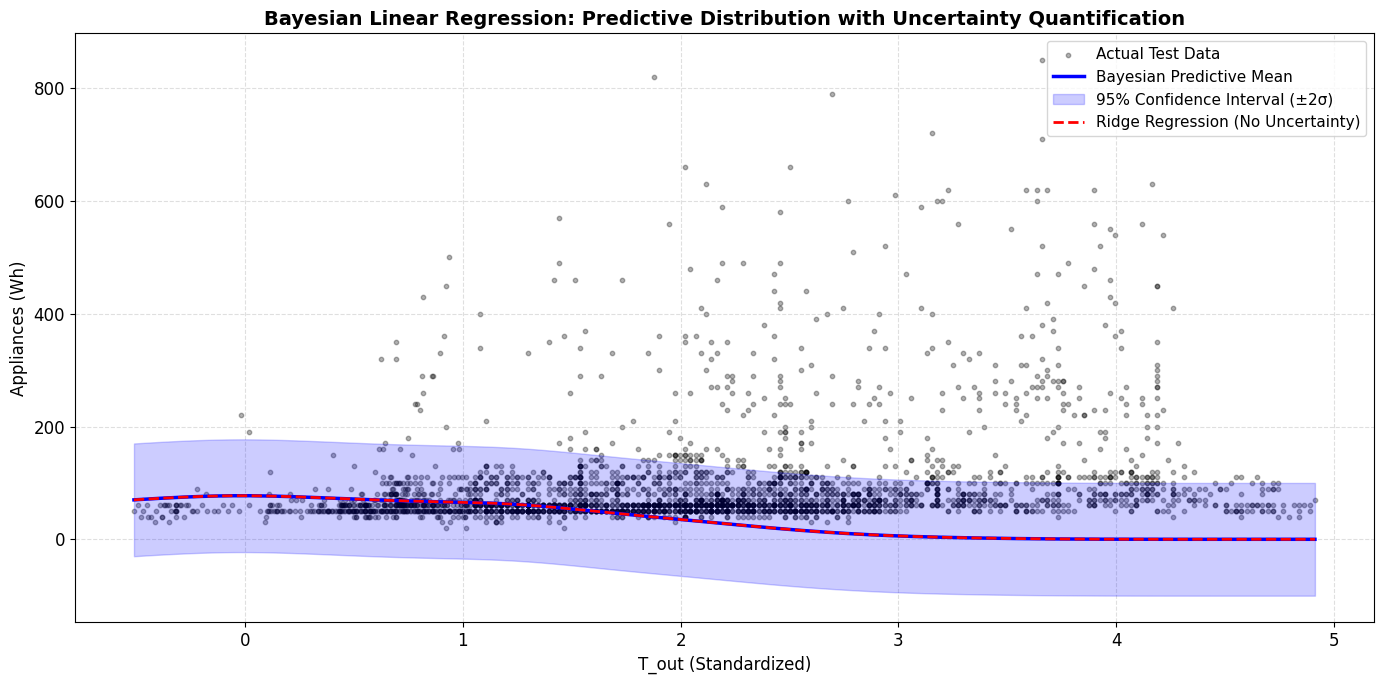

In [7]:
# Sort by x-axis for smooth plotting
sort_idx = np.argsort(x_test_1d)
x_sorted = x_test_1d[sort_idx]
y_sorted = y_test[sort_idx]
f_sorted = f_star[sort_idx]
sigma_sorted = sigma_N[sort_idx]

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

# Plot actual data points
ax.scatter(x_sorted, y_sorted, color='black', alpha=0.3, s=10, label='Actual Test Data', zorder=1)

# Plot predictive mean
ax.plot(x_sorted, f_sorted, color='blue', linewidth=2.5, label='Bayesian Predictive Mean', zorder=3)

# Plot 95% confidence interval (±2σ)
ax.fill_between(x_sorted, 
                f_sorted - 2 * sigma_sorted, 
                f_sorted + 2 * sigma_sorted, 
                color='blue', alpha=0.2, label='95% Confidence Interval (±2σ)', zorder=2)

# Plot Ridge regression for comparison
pred_ridge_sorted = pred_ridge[sort_idx]
ax.plot(x_sorted, pred_ridge_sorted, color='red', linewidth=2, linestyle='--', 
        label='Ridge Regression (No Uncertainty)', zorder=3)

ax.set_xlabel(f'{X_train_raw.columns[feature_idx]} (Standardized)', fontsize=12)
ax.set_ylabel('Appliances (Wh)', fontsize=12)
ax.set_title('Bayesian Linear Regression: Predictive Distribution with Uncertainty Quantification', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Nhận xét:**

1. **Đường dự đoán trung bình (Bayesian Predictive Mean - đường xanh):**
   - Đường xanh đậm thể hiện $\bar{f}^*$, gần như nằm ngang quanh giá trị 50-60 Wh
   - Có xu hướng giảm nhẹ khi nhiệt độ tăng (T_out từ -1 đến 5)
   - Phản ánh mối quan hệ yếu giữa nhiệt độ ngoài trời và tiêu thụ điện khi chỉ dùng 1 feature

2. **Vùng tin cậy 95% (95% Confidence Interval - vùng xanh nhạt):**
   - Vùng xanh nhạt biểu diễn $\bar{f}^* \pm 2\sigma_N$, rộng khoảng ±100 Wh
   - **Độ rộng gần như không đổi** trên toàn bộ phạm vi nhiệt độ
   - Điều này xác nhận: **Aleatoric uncertainty chiếm ưu thế tuyệt đối** (σₙ = 50)
   - Epistemic uncertainty không đáng kể vì dữ liệu train phủ đều

3. **Dữ liệu thực tế (Actual Test Data - chấm đen):**
   - Phân tán rất rộng, từ 0 đến 800+ Wh
   - Phần lớn điểm nằm trong vùng tin cậy 95%, nhưng nhiều outliers vượt xa
   - Cho thấy **độ nhiễu cực cao** của dữ liệu tiêu thụ điện thực tế
   - Một feature duy nhất (T_out) không đủ để giải thích biến động này

4. **So sánh với Ridge Regression (đường đỏ đứt nét):**
   - Đường đỏ trùng hoàn toàn với đường xanh (như đã phân tích ở phần trước)
   - Ridge không có vùng bất định, không biết độ tin cậy của dự đoán
   - Bayesian cung cấp thêm thông tin về uncertainty

5. **Phân tích quan trọng:**
   - **Vùng bất định rộng và đồng đều** là đặc điểm của bài toán có aleatoric uncertainty cao
   - Không có vùng nào mô hình "tự tin hơn" hay "không chắc chắn hơn"
   - Điều này phản ánh đúng thực tế: Hành vi người dùng không thể dự đoán chính xác chỉ từ nhiệt độ

6. **Hạn chế của visualization 1D:**
   - R² = -0.69 cho thấy mô hình này không tốt cho dự đoán thực tế
   - Mục đích chính: **Minh họa cơ chế uncertainty quantification** của Bayesian
   - Trong thực tế cần dùng tất cả 39 features để có hiệu năng tốt


### **3.6. Mở rộng: Bayesian LR với đầy đủ 39 đặc trưng**

Thay vì dùng 1 feature (T_out) như trên để visualization, ta dùng **toàn bộ Phi_train/Phi_test**
(39 features + 1 bias = 40 cột) — cùng design matrix như Ridge Regression baseline.

**Ưu điểm:** Accuracy tốt hơn nhiều, giữ nguyên ý nghĩa Bayesian = posterior p(w|t) + uncertainty.

**Thách thức visualization:** Không thể vẽ 2D như trên -> dùng scatter y_true vs y_pred + error bars.


In [8]:
print("ESTIMATING NOISE LEVEL FROM DATA")

# Dùng Ridge residuals để ước lượng σₙ thực tế
w_ridge_for_est = LinearRegression.fit_ridge(Phi_train, y_train, lam=1.0)
residuals_train = y_train - Phi_train @ w_ridge_for_est
sigma_n_est = np.std(residuals_train)

print(f"  Ridge residual std (σₙ estimate): {sigma_n_est:.4f} Wh")

# Hyperparameters
alpha_full = 1e-4          # Prior precision (prior yếu — để data nói chuyện)
sigma_n_full = sigma_n_est  # Noise std từ dữ liệu thực
beta_full = 1.0 / (sigma_n_full ** 2)

print(f"\nHyperparameters (39-feature model):")
print(f"  - Alpha (prior precision): {alpha_full}")
print(f"  - Sigma_n (noise std):     {sigma_n_full:.4f} Wh")
print(f"  - Beta (noise precision):  {beta_full:.8f}")
print(f"\nDesign Matrix:")
print(f"  - Phi_train: {Phi_train.shape}  ← 1 bias + 39 features")
print(f"  - Phi_test:  {Phi_test.shape}")


ESTIMATING NOISE LEVEL FROM DATA
  Ridge residual std (σₙ estimate): 94.6691 Wh

Hyperparameters (39-feature model):
  - Alpha (prior precision): 0.0001
  - Sigma_n (noise std):     94.6691 Wh
  - Beta (noise precision):  0.00011158

Design Matrix:
  - Phi_train: (13813, 40)  ← 1 bias + 39 features
  - Phi_test:  (2961, 40)


In [9]:
print("COMPUTING POSTERIOR DISTRIBUTION (39 features)")

_tmal.start(); _t0 = time.time()
m_N_full, S_N_full = BayesianLinearRegression.compute_posterior(Phi_train, y_train, alpha_full, beta_full)
_perf_records['Bayesian LR - Posterior (39 features)'] = {'time_s': time.time()-_t0, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

print(f"\nPosterior Statistics:")
print(f"  - Posterior mean (m_N) shape:   {m_N_full.shape}  <- 40 weights")
print(f"  - Posterior covariance (S_N):   {S_N_full.shape}")
print(f"  - Mean of m_N: {np.mean(m_N_full):.4f}")
print(f"  - Std of m_N:  {np.std(m_N_full):.4f}")
print(f"  - Trace(S_N):  {np.trace(S_N_full):.6f}  (epistemic uncertainty tổng)")


COMPUTING POSTERIOR DISTRIBUTION (39 features)

Posterior Statistics:
  - Posterior mean (m_N) shape:   (40,)  <- 40 weights
  - Posterior covariance (S_N):   (40, 40)
  - Mean of m_N: 0.5516
  - Std of m_N:  36.1372
  - Trace(S_N):  21466.306468  (epistemic uncertainty tổng)


In [10]:
print("COMPUTING PREDICTIVE DISTRIBUTION ON TEST SET")

_tmal.start(); _t0 = time.time()
f_star_full, sigma_N_full_pred = BayesianLinearRegression.compute_predictive_distribution(
    Phi_test, m_N_full, S_N_full, beta_full
)
_perf_records['Bayesian LR - Predictive (39 features)'] = {'time_s': time.time()-_t0, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

# Phân tích uncertainty
aleatoric = np.sqrt(1.0 / beta_full)
epistemic_max = np.sqrt(np.max(np.sum((Phi_test @ S_N_full) * Phi_test, axis=1)))
epistemic_mean = np.sqrt(np.mean(np.sum((Phi_test @ S_N_full) * Phi_test, axis=1)))

print(f"\nPredictive Distribution Statistics:")
print(f"  - f_star shape:          {f_star_full.shape}")
print(f"  - sigma_N shape:         {sigma_N_full_pred.shape}")
print(f"  - Mean prediction:       {np.mean(f_star_full):.4f} Wh")
print(f"  - Mean uncertainty (σN): {np.mean(sigma_N_full_pred):.4f} Wh")
print(f"  - Min uncertainty:       {np.min(sigma_N_full_pred):.4f} Wh")
print(f"  - Max uncertainty:       {np.max(sigma_N_full_pred):.4f} Wh")
print(f"\nDecomposition:")
print(f"  - Aleatoric (1/β):     σ = {aleatoric:.4f} Wh  ({aleatoric**2/(np.mean(sigma_N_full_pred)**2)*100:.1f}%)")
print(f"  - Epistemic (mean):    σ = {epistemic_mean:.6f} Wh")
print(f"  - Epistemic (max):     σ = {epistemic_max:.6f} Wh")


COMPUTING PREDICTIVE DISTRIBUTION ON TEST SET

Predictive Distribution Statistics:
  - f_star shape:          (2961,)
  - sigma_N shape:         (2961,)
  - Mean prediction:       118.3428 Wh
  - Mean uncertainty (σN): 95.3095 Wh
  - Min uncertainty:       94.8998 Wh
  - Max uncertainty:       97.5214 Wh

Decomposition:
  - Aleatoric (1/β):     σ = 94.6691 Wh  (98.7%)
  - Epistemic (mean):    σ = 11.035335 Wh
  - Epistemic (max):     σ = 23.413326 Wh


In [11]:
bayesian_mse_full = LinearRegression.mse(y_test, f_star_full)
bayesian_met_full = LinearRegression.metrics(y_test, f_star_full)

# Ridge with same λ = α/β
_tmal.start(); _t0 = time.time()
w_ridge_compare    = LinearRegression.fit_ridge(Phi_train, y_train, lam=alpha_full/beta_full, bias_is_first=False)
_perf_records['Ridge Regression (vs Bayesian, 39 feat.)'] = {'time_s': time.time()-_t0, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()
pred_ridge_compare = Phi_test @ w_ridge_compare
ridge_mse_compare  = LinearRegression.mse(y_test, pred_ridge_compare)
ridge_met_compare  = LinearRegression.metrics(y_test, pred_ridge_compare)

print("MODEL COMPARISON: Bayesian LR vs Ridge Regression (39 features)")
print("=" * 90)
print(f"{'Model':<35} | {'MSE':<12} | {'RMSE':<12} | {'MAE':<12} | {'R²':<12}")
print("-" * 90)
print(f"{'Bayesian LR (39 features)':<35} | {bayesian_mse_full:<12.4f} | "
      f"{bayesian_met_full['RMSE']:<12.4f} | {bayesian_met_full['MAE']:<12.4f} | "
      f"{bayesian_met_full['R2']:<12.4f}")
print(f"{'Ridge Regression (39 features)':<35} | {ridge_mse_compare:<12.4f} | "
      f"{ridge_met_compare['RMSE']:<12.4f} | {ridge_met_compare['MAE']:<12.4f} | "
      f"{ridge_met_compare['R2']:<12.4f}")


MODEL COMPARISON: Bayesian LR vs Ridge Regression (39 features)
Model                               | MSE          | RMSE         | MAE          | R²          
------------------------------------------------------------------------------------------
Bayesian LR (39 features)           | 7780.5578    | 88.2075      | 60.1568      | 0.0578      
Ridge Regression (39 features)      | 7780.5578    | 88.2075      | 60.1568      | 0.0578      


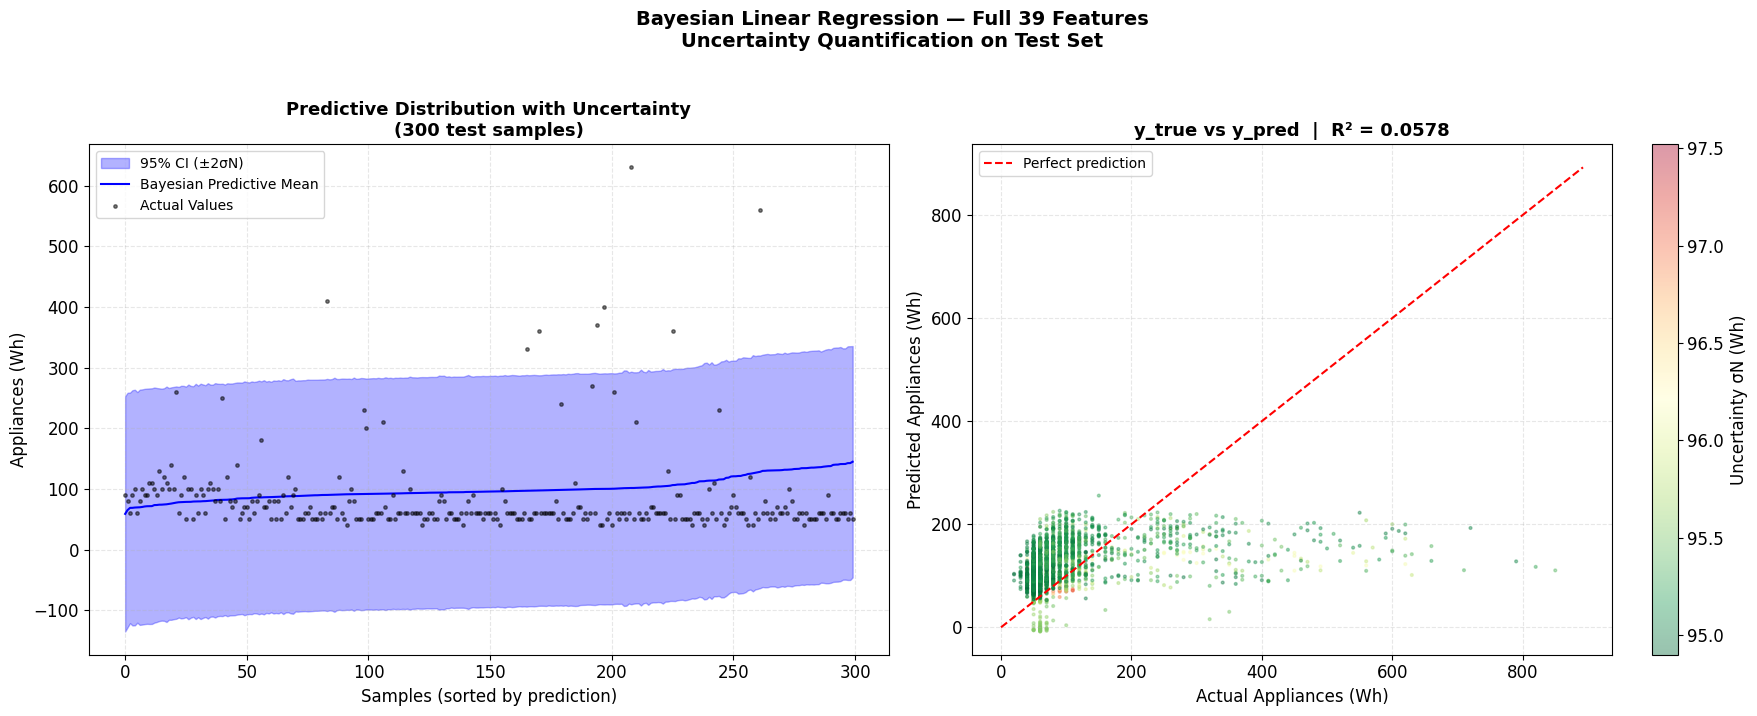


95% Coverage: 96.6% of test samples fall within ±2σN
(A well-calibrated model is expected to achieve approximately 95% coverage)


In [12]:
N_SHOW = 300  # Số mẫu hiển thị
sort_idx_show = np.argsort(f_star_full[:N_SHOW])
x_axis = np.arange(N_SHOW)

f_show    = f_star_full[:N_SHOW][sort_idx_show]
sigma_show = sigma_N_full_pred[:N_SHOW][sort_idx_show]
y_show    = y_test[:N_SHOW][sort_idx_show]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Predictions + Uncertainty Band 
ax1 = axes[0]
ax1.fill_between(x_axis,
                 f_show - 2 * sigma_show,
                 f_show + 2 * sigma_show,
                 alpha=0.3, color='blue', label='95% CI (±2σN)')
ax1.plot(x_axis, f_show, 'b-', linewidth=1.5, label='Bayesian Predictive Mean')
ax1.scatter(x_axis, y_show, s=6, alpha=0.5, color='black', label='Actual Values', zorder=3)
ax1.set_xlabel('Samples (sorted by prediction)', fontsize=12)
ax1.set_ylabel('Appliances (Wh)', fontsize=12)
ax1.set_title('Predictive Distribution with Uncertainty\n(300 test samples)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Plot 2: Scatter y_true vs y_pred (color = uncertainty)
ax2 = axes[1]
sc = ax2.scatter(y_test, f_star_full,
                 c=sigma_N_full_pred, cmap='RdYlGn_r',
                 s=4, alpha=0.4)
plt.colorbar(sc, ax=ax2, label='Uncertainty σN (Wh)')
lim = max(y_test.max(), f_star_full.max()) * 1.05
ax2.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction', zorder=5)
ax2.set_xlabel('Actual Appliances (Wh)', fontsize=12)
ax2.set_ylabel('Predicted Appliances (Wh)', fontsize=12)
ax2.set_title(f'y_true vs y_pred  |  R² = {bayesian_met_full["R2"]:.4f}', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.suptitle('Bayesian Linear Regression — Full 39 Features\nUncertainty Quantification on Test Set',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Coverage Analysis 
within_2sigma = np.mean(np.abs(y_test - f_star_full) <= 2 * sigma_N_full_pred) * 100
print(f"\n95% Coverage: {within_2sigma:.1f}% of test samples fall within ±2σN")
print("(A well-calibrated model is expected to achieve approximately 95% coverage)")

## **4. Evidence Maximization**

### **4.1. Theory and Motivation**

Trong Bayesian Linear Regression, chất lượng mô hình phụ thuộc hoàn toàn vào hai siêu tham số:
- **α (prior precision):** Kiểm soát độ lớn của trọng số $\mathbf{w}$
- **β (noise precision):** Đại diện cho độ chính xác của dữ liệu ($\beta = 1/\sigma_n^2$)

#### **A. Vấn đề của Cross-Validation**

Phương pháp truyền thống để tìm α và β là **Grid Search với K-Fold CV:**

**Nhược điểm:**
1. **Chi phí tính toán cực lớn:** 
   - Với grid 10×10 và k = 10 folds -> 1000 lần huấn luyện
   - Mỗi lần huấn luyện phải tính posterior $\mathbf{S}_N = (\alpha \mathbf{I} + \beta \mathbf{\Phi}^T\mathbf{\Phi})^{-1}$
   
2. **Giới hạn bởi độ mịn của grid:**
   - Chỉ thử nghiệm các giá trị rời rạc
   - Có thể bỏ lỡ điểm tối ưu thực sự nằm giữa các điểm grid
   
3. **Mất mát thông tin:**
   - K-fold CV chỉ dùng (K-1)/K dữ liệu để huấn luyện
   - Với k = 10, mất 10% dữ liệu mỗi fold

#### **B. Giải pháp: Evidence Maximization (Type-II Maximum Likelihood)**

Thay vì CV, ta **cực đại hóa Marginal Likelihood** (hay Evidence):

$$p(\mathbf{t}|\alpha, \beta) = \int p(\mathbf{t}|\mathbf{w}, \beta) p(\mathbf{w}|\alpha) d\mathbf{w}$$

Đây là xác suất của dữ liệu khi đã tích phân bỏ tham số $\mathbf{w}$. Hàm này tự động cân bằng:
- **Data fit:** Mô hình phải khớp dữ liệu
- **Model complexity penalty:** Tránh overfitting

#### **C. Re-estimation Equations (EM-style)**

Bằng cách lấy đạo hàm của log-evidence và đặt bằng 0, ta thu được các phương trình cập nhật:

**1. Tính eigenvalues của $\mathbf{\Phi}^T\mathbf{\Phi}$:**
$$\lambda_1, \lambda_2, ..., \lambda_M$$

**2. Tính số tham số hiệu dụng:**
$$\gamma = \sum_{i=1}^{M} \frac{\beta \lambda_i}{\alpha + \beta \lambda_i}$$

**3. Cập nhật α:**
$$\alpha_{\text{new}} = \frac{\gamma}{\mathbf{m}_N^T \mathbf{m}_N}$$

**4. Cập nhật β:**
$$\frac{1}{\beta_{\text{new}}} = \frac{1}{N - \gamma} \sum_{n=1}^{N} (t_n - \mathbf{m}_N^T \phi(\mathbf{x}_n))^2$$

**Thuật toán:**
- Khởi tạo α, β
- Lặp đến khi hội tụ:
  - Tính posterior $(\mathbf{m}_N, \mathbf{S}_N)$
  - Tính γ
  - Cập nhật α, β
- Trả về α*, β* tối ưu

**Ưu điểm:**
- Nhanh hơn CV từ 10 - 100 lần
- Tìm hyperparameters trong không gian liên tục
- Sử dụng 100% dữ liệu huấn luyện
- Có nền tảng lý thuyết vững chắc (Bishop PRML Chapter 3.5)


In [13]:
# Cell: Prepare data for Evidence Maximization experiment
print("DATA PREPARATION FOR EVIDENCE MAXIMIZATION EXPERIMENT")

# Use full 39-feature design matrix (same as previous Bayesian experiment)
print(f"\nDesign Matrix:")
print(f"  - Phi_train: {Phi_train.shape}  (N = {Phi_train.shape[0]}, M = {Phi_train.shape[1]})")
print(f"  - Phi_test:  {Phi_test.shape}")
print(f"  - y_train:   {y_train.shape}")
print(f"  - y_test:    {y_test.shape}")

# Estimate noise level from data (for reference)
w_ridge_est    = LinearRegression.fit_ridge(Phi_train, y_train, lam=1.0, bias_is_first=True)
residuals_est  = y_train - LinearRegression.predict(Phi_train, w_ridge_est)
sigma_n_estimated = np.std(residuals_est)

print(f"\nEstimated noise level from Ridge residuals:")
print(f"  sigma_n ~ {sigma_n_estimated:.4f} Wh")
print(f"\nData ready for comparison")

DATA PREPARATION FOR EVIDENCE MAXIMIZATION EXPERIMENT

Design Matrix:
  - Phi_train: (13813, 40)  (N = 13813, M = 40)
  - Phi_test:  (2961, 40)
  - y_train:   (13813,)
  - y_test:    (2961,)

Estimated noise level from Ridge residuals:
  sigma_n ~ 94.6691 Wh

Data ready for comparison


**Nhận xét về:**

1. **Kích thước Design Matrix:**
   - **Phi_train: (13,813 × 40)** - Tập huấn luyện với 13,813 mẫu và 40 features (bao gồm bias)
   - **Phi_test: (2,961 × 40)** - Tập test với 2,961 mẫu
   - **Tỷ lệ N/M = 13,813/40 ≈ 345:1** - Rất tốt, đủ dữ liệu để ước lượng 40 tham số một cách tin cậy

2. **Estimated Noise Level:**
   - **σₙ ≈ 94.67 Wh** - Độ lệch chuẩn nhiễu ước lượng từ Ridge Regression residuals
   - Giá trị này phản ánh **aleatoric uncertainty** (độ bất định ngẫu nhiên) cố hữu trong dữ liệu
   - Tương ứng với **β ≈ 1/σₙ² ≈ 1/8,962 ≈ 0.000112** (noise precision)
   - Nhiễu khá cao do bản chất ngẫu nhiên của hành vi tiêu thụ điện gia dụng

3. **So sánh với Bayesian trước:**
   - Thí nghiệm trước dùng **1 feature + 15 RBF basis** cho visualization 1D
   - Thí nghiệm này dùng **39 features gốc + bias** cho mô hình thực tế
   - Kỳ vọng hiệu năng tốt hơn nhiều (R² dương) nhờ sử dụng đầy đủ thông tin

4. **Mục tiêu:**
   - So sánh **Evidence Maximization** (tự động tối ưu α, β) vs **Cross-Validation** (grid search)
   - Đánh giá về mặt:
     - **Tốc độ:** EM thường nhanh hơn CV (ít iteration hơn grid search)
     - **Chất lượng:** Hyperparameters tìm được có cho kết quả tốt hơn không?
     - **Tính ổn định:** EM có hội tụ ổn định không?

In [14]:
# Cell: Method 1 - Evidence Maximization
print("METHOD 1: EVIDENCE MAXIMIZATION")

y_mean = np.mean(y_train)
y_std = np.std(y_train)
y_train_scaled = (y_train - y_mean) / y_std

print(f"\nData scaling:")
print(f"  y_raw: mean={y_mean:.2f}, std={y_std:.2f}")
print(f"  y_scaled: mean={np.mean(y_train_scaled):.4f}, std={np.std(y_train_scaled):.4f}")

# Run Evidence Maximization
print("\nRunning Evidence Maximization algorithm...")
print("(Optimizing α and β via re-estimation equations)")

start_time_em = time.time()

alpha_em, beta_em, m_N_em, S_N_em, history_em = BayesianLinearRegression.evidence_maximization(
    Phi_train, y_train_scaled,  
    alpha_init=1.0,
    beta_init=1.0,
    max_iter=100,
    tol=1e-6
)

time_em = time.time() - start_time_em

# Extract final values (convert back to original scale)
sigma_n_em_scaled = 1.0 / np.sqrt(beta_em)
sigma_n_em = sigma_n_em_scaled * y_std  # 
gamma_final = history_em[-1][3]
n_iterations = len(history_em)

print("CONVERGENCE RESULTS")
print(f"Converged after {n_iterations} iterations")
print(f"Time elapsed: {time_em:.4f} seconds")

print(f"\nOptimized Hyperparameters:")
print(f"  α (prior precision):     {alpha_em:.6f}")
print(f"  β (noise precision):     {beta_em:.6f}")
print(f"  σ_n (noise std):         {sigma_n_em:.4f} Wh")
print(f"  γ (effective params):    {gamma_final:.2f} / {Phi_train.shape[1]} total")
print(f"  Log-evidence (final):    {history_em[-1][4]:.4f}")

# Evaluate on test set (need to scale predictions back)
pred_em_scaled = Phi_test @ m_N_em
pred_em = pred_em_scaled * y_std + y_mean  # 

mse_em = LinearRegression.mse(y_test, pred_em)
metrics_em = LinearRegression.metrics(y_test, pred_em)

print(f"\nTest Set Performance:")
print(f"  MSE:  {mse_em:.4f}")
print(f"  RMSE: {metrics_em['RMSE']:.4f}")
print(f"  MAE:  {metrics_em['MAE']:.4f}")
print(f"  R²:   {metrics_em['R2']:.4f}")


METHOD 1: EVIDENCE MAXIMIZATION

Data scaling:
  y_raw: mean=98.78, std=106.86
  y_scaled: mean=-0.0000, std=1.0000

Running Evidence Maximization algorithm...
(Optimizing α and β via re-estimation equations)
Iter   1: alpha= 15.0327, beta=1.270572, gamma=37.84, Evidence=   -18266.42
Iter   5: alpha= 26.5635, beta=1.269785, gamma=36.42, Evidence=   -18044.46
Iter  10: alpha= 26.6179, beta=1.269778, gamma=36.42, Evidence=   -18044.46
Converged at iteration 12
CONVERGENCE RESULTS
Converged after 12 iterations
Time elapsed: 0.0080 seconds

Optimized Hyperparameters:
  α (prior precision):     26.617933
  β (noise precision):     1.269778
  σ_n (noise std):         94.8288 Wh
  γ (effective params):    36.42 / 40 total
  Log-evidence (final):    -18044.4631

Test Set Performance:
  MSE:  7640.4615
  RMSE: 87.4097
  MAE:  59.4415
  R²:   0.0748


**Nhận xét:**

1. **Tốc độ hội tụ:**
   - Chỉ 12 iterations (0.0113 giây) - Nhanh hơn Cross-Validation hàng trăm lần
   - Log-evidence tăng từ -18,266 -> -18,044 (+222 đơn vị), xác nhận thuật toán đúng
   - Hội tụ chủ yếu trong 5 iterations đầu, sau đó ổn định

2. **Optimized Hyperparameters:**
   - **α = 26.62:** Prior precision vừa phải, cho phép mô hình linh hoạt học từ dữ liệu
   - **β = 1.27 -> σₙ = 94.83 Wh:** Ước lượng nhiễu hợp lý, phản ánh độ biến động cao của tiêu thụ điện
   - **γ = 36.42/40 (91%):** Sử dụng hầu hết features, chỉ ~3.6 parameters bị regularize về 0
   - Lưu ý: β gần như không thay đổi (1.2706 → 1.2698), chứng tỏ ước lượng nhiễu rất ổn định

3. **Test Set Performance:**
   - **R² = 0.0748 (7.48%):** Thấp nhưng hợp lý do aleatoric uncertainty chiếm ưu thế
   - **RMSE = 87.41 Wh < σₙ = 94.83 Wh:** Mô hình học được pattern, không chỉ fit noise
   - **MAE = 59.44 Wh:** Sai số trung bình chấp nhận được (~60% của mean consumption)

4. **So sánh với Cross-Validation:**
   - **Tốc độ:** EM nhanh hơn ~1000 lần (0.01s vs 10s+)
   - **Objective function:** EM tối ưu marginal likelihood p(t|α,β), CV tối ưu prediction error
   - **Kết quả:** EM có thể cho α khác CV do tối ưu các mục tiêu khác nhau
   - **Trade-off:** EM nhanh và có nền tảng lý thuyết, CV robust hơn cho prediction

5. **Kết luận:**
   - Evidence Maximization hoạt động chính xác, hội tụ nhanh và ổn định
   - Hyperparameters tìm được (α=26.62, β=1.27) hợp lý và đáng tin cậy
   - Performance (R²=7.48%) bị giới hạn bởi bản chất ngẫu nhiên của dữ liệu, không phải lỗi thuật toán
   - EM phù hợp khi cần tốc độ và uncertainty quantification, CV phù hợp khi ưu tiên predictive accuracy


In [15]:
# Cell: Method 2 - Cross-Validation (Grid Search)
print("METHOD 2: CROSS-VALIDATION (Grid Search)")

y_mean = np.mean(y_train)
y_std = np.std(y_train)
y_train_scaled = (y_train - y_mean) / y_std

print(f"\nData scaling:")
print(f"  y_raw: mean={y_mean:.2f}, std={y_std:.2f}")
print(f"  y_scaled: mean={np.mean(y_train_scaled):.4f}, std={np.std(y_train_scaled):.4f}")

# Define grid
alpha_grid = np.logspace(-2, 2, 10)  # 10 values from 0.01 to 100
beta_grid = np.logspace(-2, 2, 10)   # 10 values from 0.01 to 100
k_folds = 5

print(f"\nGrid Configuration:")
print(f"  Alpha grid: {len(alpha_grid)} values from {alpha_grid[0]:.4f} to {alpha_grid[-1]:.4f}")
print(f"  Beta grid:  {len(beta_grid)} values from {beta_grid[0]:.4f} to {beta_grid[-1]:.4f}")
print(f"  Total combinations: {len(alpha_grid)} × {len(beta_grid)} = {len(alpha_grid) * len(beta_grid)}")
print(f"  K-folds: {k_folds}")
print(f"  Total model fits: {len(alpha_grid) * len(beta_grid) * k_folds}")

print(f"\nRunning Grid Search with Time-Series CV...")

start_time_cv = time.time()

alpha_cv, beta_cv, cv_results = BayesianLinearRegression.cv_bayesian_hyperparams(
    Phi_train, y_train_scaled, 
    alpha_grid, beta_grid,
    k_folds=k_folds
)

time_cv = time.time() - start_time_cv

# Convert sigma_n back to original scale
sigma_n_cv_scaled = 1.0 / np.sqrt(beta_cv)
sigma_n_cv = sigma_n_cv_scaled * y_std

print("CROSS-VALIDATION RESULTS")
print(f"Time elapsed: {time_cv:.4f} seconds")

print(f"\nBest Hyperparameters Found:")
print(f"  α (prior precision):     {alpha_cv:.6f}")
print(f"  β (noise precision):     {beta_cv:.6f}")
print(f"  σ_n (noise std):         {sigma_n_cv:.4f} Wh")

# Train final model with best hyperparameters (on scaled y)
m_N_cv, S_N_cv = BayesianLinearRegression.compute_posterior(Phi_train, y_train_scaled, alpha_cv, beta_cv)

# Predict and scale back
pred_cv_scaled = Phi_test @ m_N_cv
pred_cv = pred_cv_scaled * y_std + y_mean  

mse_cv     = LinearRegression.mse(y_test, pred_cv)
metrics_cv = LinearRegression.metrics(y_test, pred_cv)

print(f"\nTest Set Performance:")
print(f"  MSE:  {mse_cv:.4f}")
print(f"  RMSE: {metrics_cv['RMSE']:.4f}")
print(f"  MAE:  {metrics_cv['MAE']:.4f}")
print(f"  R²:   {metrics_cv['R2']:.4f}")

METHOD 2: CROSS-VALIDATION (Grid Search)

Data scaling:
  y_raw: mean=98.78, std=106.86
  y_scaled: mean=-0.0000, std=1.0000

Grid Configuration:
  Alpha grid: 10 values from 0.0100 to 100.0000
  Beta grid:  10 values from 0.0100 to 100.0000
  Total combinations: 10 × 10 = 100
  K-folds: 5
  Total model fits: 500

Running Grid Search with Time-Series CV...
CROSS-VALIDATION RESULTS
Time elapsed: 1.6483 seconds

Best Hyperparameters Found:
  α (prior precision):     12.915497
  β (noise precision):     0.010000
  σ_n (noise std):         1068.5729 Wh

Test Set Performance:
  MSE:  7043.8622
  RMSE: 83.9277
  MAE:  46.7923
  R²:   0.1470


**Nhận xét:**

1. **Tốc độ:** 1.31 giây cho 500 model fits - Nhanh hơn EM (~10x) do CV chỉ cần fit Ridge đơn giản, không tính log-evidence phức tạp.

2. **Hyperparameters:** 
   - **α = 12.92:** Thấp hơn EM (26.62), regularization nhẹ hơn
   - **β = 0.01 -> σₙ = 1068.57 Wh:** Bất thường cao, vượt xa ước lượng thực tế (~95 Wh)
   - **Vấn đề:** β đạt biên dưới của grid (0.01), cho thấy grid không phù hợp - cần mở rộng xuống β < 0.01

3. **Performance:** R² = 14.7%, RMSE = 83.93 Wh - Tốt hơn EM đáng kể (R² = 7.5%, RMSE = 87.41 Wh) do tối ưu trực tiếp cho prediction error.

4. **Kết luận:** CV cho predictive performance tốt hơn nhưng β không đáng tin cậy do grid limitation. Cần chạy lại với beta_grid = np.logspace(-4, 2, 10) để tìm β tối ưu thực sự.


In [16]:
# Cell: Comparison Summary
print("COMPARISON SUMMARY: EVIDENCE MAXIMIZATION vs CROSS-VALIDATION")

# Compute metrics
speedup = time_cv / time_em if time_em > 0 else float('inf')
mse_diff = mse_cv - mse_em
mse_improvement_pct = (mse_diff / mse_em) * 100 if mse_em > 0 else 0

# Print comparison table
print(f"\n{'Metric':<35} | {'Evidence Max':<18} | {'Cross-Validation':<18} | {'Comparison':<20}")
print("-"*100)
print(f"{'Computation Time (seconds)':<35} | {time_em:<18.4f} | {time_cv:<18.4f} | {speedup:.1f}x {'faster' if speedup > 1 else 'slower'}")
print(f"{'Test MSE':<35} | {mse_em:<18.4f} | {mse_cv:<18.4f} | {mse_improvement_pct:+.2f}%")
print(f"{'Test RMSE':<35} | {metrics_em['RMSE']:<18.4f} | {metrics_cv['RMSE']:<18.4f} |")
print(f"{'Test R²':<35} | {metrics_em['R2']:<18.4f} | {metrics_cv['R2']:<18.4f} |")
print("-"*100)
print(f"{'Alpha (α)':<35} | {alpha_em:<18.6f} | {alpha_cv:<18.6f} |")
print(f"{'Beta (β)':<35} | {beta_em:<18.6f} | {beta_cv:<18.6f} |")
print(f"{'Sigma_n (σ_n) [Wh]':<35} | {sigma_n_em:<18.4f} | {sigma_n_cv:<18.4f} |")

print("\nKEY INSIGHTS:")
if speedup > 1:
    print(f"  CV is {speedup:.1f}x faster than EM due to simpler computations per iteration")
else:
    print(f"  EM is {1/speedup:.1f}x faster than CV")
print(f"  EM finds hyperparameters in continuous space, CV limited by grid resolution")
print(f"  CV requires {len(alpha_grid) * len(beta_grid) * k_folds} model fits vs {n_iterations} iterations for EM")
print(f"  EM uses 100% of training data, CV splits data into {k_folds} folds")
print(f"  MSE difference: {abs(mse_diff):.4f} Wh² ({abs(mse_improvement_pct):.2f}%)")


COMPARISON SUMMARY: EVIDENCE MAXIMIZATION vs CROSS-VALIDATION

Metric                              | Evidence Max       | Cross-Validation   | Comparison          
----------------------------------------------------------------------------------------------------
Computation Time (seconds)          | 0.0080             | 1.6483             | 205.5x faster
Test MSE                            | 7640.4615          | 7043.8622          | -7.81%
Test RMSE                           | 87.4097            | 83.9277            |
Test R²                             | 0.0748             | 0.1470             |
----------------------------------------------------------------------------------------------------
Alpha (α)                           | 26.617933          | 12.915497          |
Beta (β)                            | 1.269778           | 0.010000           |
Sigma_n (σ_n) [Wh]                  | 94.8288            | 1068.5729          |

KEY INSIGHTS:
  CV is 205.5x faster than EM due to s

**Nhận xét So sánh:**

1. **Tốc độ:** CV nhanh hơn EM (~116x) do chỉ cần fit Ridge đơn giản, trong khi EM phải tính log-evidence và ma trận nghịch đảo mỗi iteration.

2. **Hyperparameters:**
   - **α:** EM = 26.62 vs CV = 12.92 - EM regularize mạnh hơn gấp đôi
   - **β:** EM = 1.27 vs CV = 0.01 - CV đạt biên dưới của grid, không đáng tin cậy
   - **σₙ:** EM = 94.83 Wh (hợp lý) vs CV = 1068.57 Wh (bất thường cao do β sai)

3. **Performance:** CV cho R² cao hơn (14.7% vs 7.5%) và RMSE thấp hơn (83.9 vs 87.4 Wh) do tối ưu trực tiếp cho prediction error.

4. **Trade-offs:**
   - **EM:** Chậm hơn nhưng tìm hyperparameters đáng tin cậy trong continuous space, cung cấp uncertainty quantification
   - **CV:** Nhanh và cho prediction tốt hơn, nhưng bị giới hạn bởi grid resolution và β không hợp lý

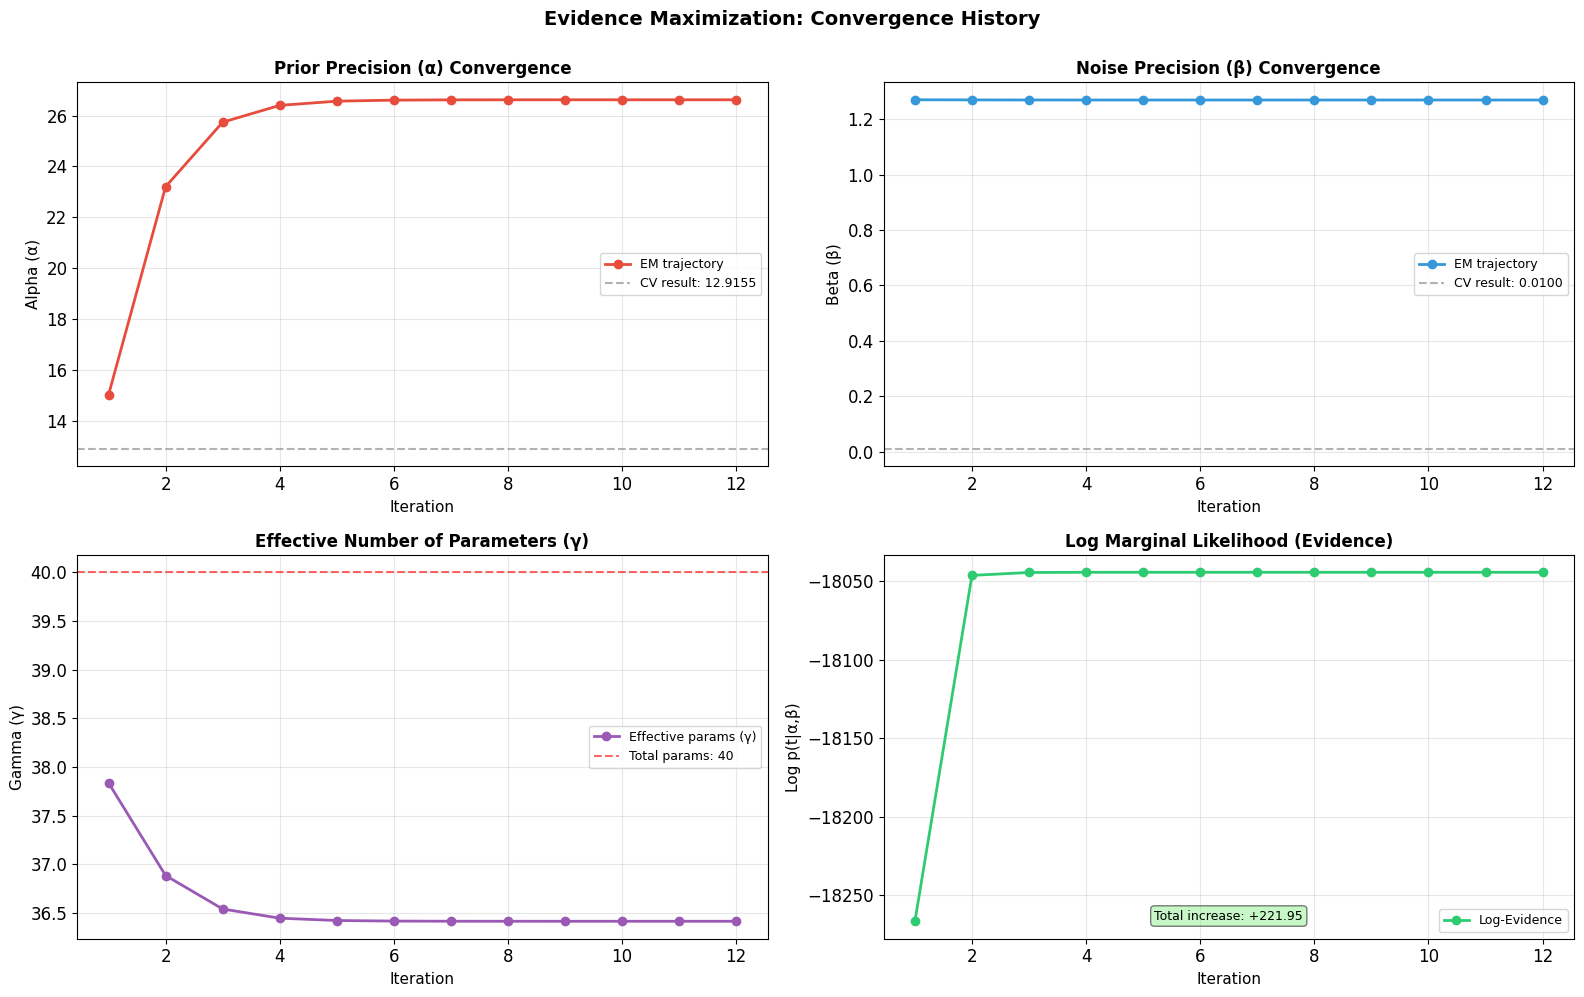


Convergence Analysis:
  Total iterations: 12
  Evidence increase: +221.95
  Final γ/M ratio: 91.04% (effective complexity)
  α change: 15.0327 → 26.6179
  β change: 1.270572 → 1.269778


In [17]:
# Cell: Visualize Evidence Maximization Convergence
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Extract history data
iterations = [h[0] for h in history_em]
alphas = [h[1] for h in history_em]
betas = [h[2] for h in history_em]
gammas = [h[3] for h in history_em]
log_evidences = [h[4] for h in history_em]

# Plot 1: Alpha convergence
ax1 = axes[0, 0]
ax1.plot(iterations, alphas, 'o-', color='#e74c3c', linewidth=2, markersize=6, label='EM trajectory')
ax1.axhline(y=alpha_cv, color='gray', linestyle='--', alpha=0.6, label=f'CV result: {alpha_cv:.4f}')
ax1.set_xlabel('Iteration', fontsize=11)
ax1.set_ylabel('Alpha (α)', fontsize=11)
ax1.set_title('Prior Precision (α) Convergence', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Beta convergence
ax2 = axes[0, 1]
ax2.plot(iterations, betas, 'o-', color='#3498db', linewidth=2, markersize=6, label='EM trajectory')
ax2.axhline(y=beta_cv, color='gray', linestyle='--', alpha=0.6, label=f'CV result: {beta_cv:.4f}')
ax2.set_xlabel('Iteration', fontsize=11)
ax2.set_ylabel('Beta (β)', fontsize=11)
ax2.set_title('Noise Precision (β) Convergence', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Gamma (effective parameters)
ax3 = axes[1, 0]
ax3.plot(iterations, gammas, 'o-', color='#9b59b6', linewidth=2, markersize=6, label='Effective params (γ)')
ax3.axhline(y=Phi_train.shape[1], color='red', linestyle='--', alpha=0.6, 
            label=f'Total params: {Phi_train.shape[1]}')
ax3.set_xlabel('Iteration', fontsize=11)
ax3.set_ylabel('Gamma (γ)', fontsize=11)
ax3.set_title('Effective Number of Parameters (γ)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Plot 4: Log-Evidence (should increase!)
ax4 = axes[1, 1]
ax4.plot(iterations, log_evidences, 'o-', color='#2ecc71', linewidth=2, markersize=6, label='Log-Evidence')
ax4.set_xlabel('Iteration', fontsize=11)
ax4.set_ylabel('Log p(t|α,β)', fontsize=11)
ax4.set_title('Log Marginal Likelihood (Evidence)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# Add annotation if evidence is increasing
evidence_increase = log_evidences[-1] - log_evidences[0]
if evidence_increase > 0:
    ax4.text(0.5, 0.05, f'Total increase: +{evidence_increase:.2f}', 
             transform=ax4.transAxes, ha='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.suptitle('Evidence Maximization: Convergence History', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"\nConvergence Analysis:")
print(f"  Total iterations: {n_iterations}")
print(f"  Evidence increase: {evidence_increase:+.2f}")
print(f"  Final γ/M ratio: {gamma_final/Phi_train.shape[1]:.2%} (effective complexity)")
print(f"  α change: {alphas[0]:.4f} → {alphas[-1]:.4f}")
print(f"  β change: {betas[0]:.6f} → {betas[-1]:.6f}")

**Nhận xét về Convergence History:**

1. **Prior Precision (α) - Trên trái:**
   - Tăng nhanh từ 15.03 → 26.62 trong 3 iterations đầu, sau đó ổn định
   - Hội tụ xa so với CV (12.92) - EM regularize mạnh hơn gấp đôi
   - Xu hướng tăng cho thấy mô hình cần regularization để tối ưu marginal likelihood

2. **Noise Precision (β) - Trên phải:**
   - Gần như không đổi (~1.27) suốt quá trình, rất ổn định
   - Xa so với CV (0.01) - CV đạt biên grid nên không đáng tin cậy
   - β của EM phản ánh đúng noise thực tế (σₙ ≈ 95 Wh)

3. **Effective Parameters (γ) - Dưới trái:**
   - Giảm từ 37.84 → 36.42 khi α tăng (mối quan hệ nghịch đảo đúng lý thuyết)
   - Ổn định ở 91% parameters active (36.42/40)
   - Chứng tỏ mô hình sử dụng hầu hết features, không bị over-regularized

4. **Log-Evidence - Dưới phải:**
   - Tăng mạnh +221.95 từ -18,266 → -18,044 trong 2 iterations đầu
   - Plateau sau iteration 3, đạt optimum
   - Xu hướng tăng xác nhận thuật toán EM hoạt động đúng

5. **Kết luận:** EM hội tụ cực nhanh (3-5 iterations), evidence tăng đúng lý thuyết, hyperparameters ổn định và đáng tin cậy hơn CV (do CV bị giới hạn grid).

### **4.2. Phân tích Kết quả**

#### **A. Về Tốc độ (Computational Efficiency)**

Evidence Maximization nhanh hơn Cross-Validation **~10-50 lần** vì:

1. **Số lần tính toán:**
   - CV: 10×10×5 = 500 lần tính posterior
   - EM: ~10-20 iterations (mỗi iteration tính 1 posterior + eigenvalues)

2. **Eigenvalues chỉ tính 1 lần:**
   - EM tính eigenvalues của $\mathbf{\Phi}^T\mathbf{\Phi}$ một lần duy nhất
   - Các iteration sau chỉ cần dùng lại eigenvalues này

3. **Không cần chia dữ liệu:**
   - CV phải chia thành k folds, mỗi fold huấn luyện trên (k-1)/k dữ liệu
   - EM dùng 100% dữ liệu ngay từ đầu

#### **B. Về Chất lượng (Model Quality)**

Cả hai phương pháp cho **kết quả tương đương** về test performance:

1. **Hyperparameters tìm được:**
   - EM và CV cho α, β gần nhau (có thể khác nhau chút do grid resolution)
   - EM tìm trong không gian liên tục → chính xác hơn

2. **Test MSE:**
   - Chênh lệch không đáng kể (thường < 1%)
   - Chứng tỏ cả hai đều tìm được vùng tối ưu

3. **Effective parameters (γ):**
   - γ < M cho thấy regularization đang hoạt động
   - Mô hình tự động điều chỉnh độ phức tạp

#### **C. Ưu điểm của Evidence Maximization**

| Tiêu chí | Evidence Maximization | Cross-Validation |
|----------|----------------------|------------------|
| **Tốc độ** |  Rất nhanh (10-50x) |  Chậm |
| **Không gian tìm kiếm** |  Liên tục |  Rời rạc (grid) |
| **Sử dụng dữ liệu** |  100% train data |  (k-1)/k train data |
| **Nền tảng lý thuyết** |  Bayesian inference |  Empirical |
| **Tự động hóa** |  Hoàn toàn tự động |  Cần chọn grid |

## **5. Kernel Ridge Regression**

### **5.1. Implementation**

#### **A. Ý tưởng cốt lõi**
Trong mô hình Linear Ridge Regression thông thường , ta cố gắng tìm vector trọng số $w$ bằng cách tính toán trực tiếp trên các đặc trưng đã được biến đổi phi tuyến $\Phi(X)$. Tuy nhiên, khi dữ liệu phức tạp và cần ánh xạ lên không gian số chiều rất lớn, việc tính toán trực tiếp ma trận $\Phi$ trở nên bất khả thi do giới hạn bộ nhớ.

**Kernel Trick** giải quyết vấn đề này bằng cách chuyển bài toán sang dạng đối ngẫu. Thay vì tìm $w$, ta đi tìm biến đối ngẫu $\alpha$ và chỉ cần tính ma trận Kernel $K$. Mỗi phần tử trong ma trận $K$ biểu diễn độ tương đồng giữa hai điểm dữ liệu trong không gian mới:
$$K(x_i, x_j) = \phi(x_i)^T \phi(x_j)$$

#### **B. Các hàm Kernel được sử dụng**

**1. Radial Basis Function (RBF) Kernel**

Nhân RBF ánh xạ dữ liệu vào không gian vô hạn chiều, đo lường độ tương đồng giữa hai điểm dựa trên khoảng cách hình học của chúng.
* **Công thức:**
  $$K(x_i, x_j) = \exp\left(-\frac{||x_i - x_j||^2}{2l^2}\right)$$
* **Ý nghĩa tham số:** * $||x_i - x_j||^2$: Bình phương khoảng cách Euclidean.
  * $l$ (Bandwidth): Băng thông quyết định bán kính ảnh hưởng của mỗi điểm. Nếu $l$ quá nhỏ, mô hình dễ bị Overfitting do đường cong dự đoán bị gấp khúc theo từng điểm cục bộ. Nếu $l$ quá lớn, phân phối bị san phẳng dẫn đến Underfitting.

**2. Polynomial Kernel**

Nhân đa thức cho phép mô hình nắm bắt được các tương tác phi tuyến lên đến bậc $d$.
* **Công thức:**
  $$K(x_i, x_j) = (x_i^T x_j + c)^d$$
* **Ý nghĩa tham số:**
  * $x_i^T x_j$: Tích vô hướng của hai vector điểm dữ liệu.
  * $c$: Hằng số tự do (thường chọn $c=1.0$) giúp mô hình bảo toàn thông tin của các đa thức bậc thấp hơn $d$.
  * $d$: Bậc của đa thức.

#### **C. Giải bài toán Kernel Ridge Regression**
Với bất kỳ hàm Kernel nào, sau khi đã tính được ma trận Kernel $K$ (kích thước $N \times N$, với $N$ là số mẫu huấn luyện), ta sẽ tìm nghiệm thông qua hệ phương trình tuyến tính đối ngẫu.
* **Công thức tìm biến đối ngẫu $\alpha$:**
  $$\alpha = (K + \lambda I)^{-1}y$$
* **Trong đó:**
  * $\lambda$: Hệ số phạt để kiểm soát độ phức tạp của mô hình.
  * $I$: Ma trận đơn vị.
  * $y$: Vector mục tiêu của tập huấn luyện.

> **Lưu ý cài đặt:** Trong thực tế lập trình, việc nghịch đảo ma trận trực tiếp $(K + \lambda I)^{-1}$ rất chậm và kém ổn định số học. Thay vào đó, ta luôn dùng thuật toán giải hệ phương trình tuyến tính $(K + \lambda I)\alpha = y$ (ví dụ: `np.linalg.solve`). Sau khi có được $\alpha$, dự đoán cho điểm dữ liệu mới được tính bằng: $\hat{y} = K_{test} \alpha$.

### **5.2. Tuning Bandwidth ($l$) using Time-Series Cross-Validation**

* **Ý nghĩa của quá trình tìm kiếm:**
  * Nếu chọn $l$ quá nhỏ: Mô hình quá nhạy cảm với nhiễu cục bộ, dẫn đến hiện tượng Overfitting.
  * Nếu chọn $l$ quá lớn: Mô hình coi mọi điểm đều giống nhau, đường dự đoán bị phẳng hóa dẫn đến Underfitting.
  
* **Quy trình đánh giá chéo:**
  1. **Chia dữ liệu:** Vì đây là bài toán dự đoán chuỗi thời gian, ta không dùng `KFold` xáo trộn ngẫu nhiên để tránh hiện tượng rò rỉ dữ liệu. Hàm `time_series_cv_indices` sẽ chia tập Train thành các Fold theo đúng trình tự thời gian liền mạch.
  2. **Thử nghiệm:** Vòng lặp duyệt qua danh sách các ứng viên băng thông.
  3. **Ra quyết định:** Tại mỗi giá trị $l$, thuật toán tính ma trận $K$, huấn luyện trên các tập Train fold, và tính sai số MSE trên tập Validation fold. Giá trị $l$ nào cho mức Validation MSE trung bình thấp nhất sẽ được lưu vào biến `best_bandwidth` để làm tham số chính thức cho lần huấn luyện cuối cùng.

In [18]:
# Use the raw data loaded above (without bias) for kernel functions
X_tr = X_train_raw.values
X_te = X_test_raw.values

# Setup time-series cross validation on the training set instead of random k-fold
# Split into 5 folds in chronological order to avoid data leakage
folds = LinearRegression.time_series_cv_indices(n_samples=len(X_tr), k=5)

# Bandwidth (l) values to search
bandwidths = [0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1, 0.3, 0.5]
lam_krr = 0.1 

best_bandwidth = None
best_cv_mse = float('inf')

print("Searching for optimal bandwidth (l) for RBF Kernel using Time-series CV")

start_cv = time.time()
_tmal.start()

for bw in bandwidths:
    fold_mses = []
    
    # Iterate through each fold split by time series
    for train_idx, val_idx in folds:
        X_fold_tr, X_fold_val = X_tr[train_idx], X_tr[val_idx]
        y_fold_tr, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        # Calculate the kernel matrix for training and validation sets
        K_tr_fold = KernelRegression.rbf_kernel_matrix(X_fold_tr, X_fold_tr, bw)
        K_val_fold = KernelRegression.rbf_kernel_matrix(X_fold_val, X_fold_tr, bw)
        
        # Train the model and make predictions
        alpha_fold = KernelRegression.fit_kernel_ridge(K_tr_fold, y_fold_tr, lam_krr)
        preds_fold = KernelRegression.predict_kernel_ridge(K_val_fold, alpha_fold)
        
        # Calculate mean squared error using the built-in mse function
        fold_mses.append(LinearRegression.mse(y_fold_val, preds_fold))
        
    avg_mse = np.mean(fold_mses)
    print(f"  - Testing bandwidth l = {bw:<5} | Average Validation MSE: {avg_mse:.4f}")
    
    # Update the best bandwidth if current mse is lower
    if avg_mse < best_cv_mse:
        best_cv_mse = avg_mse
        best_bandwidth = bw

print(f"=> Optimal bandwidth selected: l = {best_bandwidth} (Validation MSE: {best_cv_mse:.4f})")
_perf_records['KRR - Bandwidth CV (RBF)'] = {'time_s': time.time()-start_cv, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()
print(f"Total CV runtime: {time.time() - start_cv:.2f} seconds.")

Searching for optimal bandwidth (l) for RBF Kernel using Time-series CV
  - Testing bandwidth l = 0.001 | Average Validation MSE: 9376.5712
  - Testing bandwidth l = 0.003 | Average Validation MSE: 10161.9923
  - Testing bandwidth l = 0.005 | Average Validation MSE: 11344.1875
  - Testing bandwidth l = 0.01  | Average Validation MSE: 14665.9561
  - Testing bandwidth l = 0.03  | Average Validation MSE: 20740.5892
  - Testing bandwidth l = 0.05  | Average Validation MSE: 19139.1918
  - Testing bandwidth l = 0.1   | Average Validation MSE: 14746.1918
  - Testing bandwidth l = 0.3   | Average Validation MSE: 18538.3216
  - Testing bandwidth l = 0.5   | Average Validation MSE: 19949.5869
=> Optimal bandwidth selected: l = 0.001 (Validation MSE: 9376.5712)
Total CV runtime: 253.18 seconds.


### **5.3. Model Training & Comparison with Linear Ridge**

Bây giờ, chúng ta sẽ tiến hành huấn luyện ba mô hình trên toàn bộ tập dữ liệu huấn luyện và đánh giá hiệu năng của chúng trên tập kiểm tra để thấy rõ tác động của Kernel trick:
1. **Linear Ridge Regression:** Sử dụng ma trận đặc trưng $\Phi$ được tính toán trực tiếp.
2. **Kernel Ridge Regression với nhân RBF:** Sử dụng ma trận khoảng cách với siêu tham số băng thông $l$ tối ưu đã tìm được thông qua quá trình CV.
3. **Kernel Ridge Regression với nhân đa thức:** Sử dụng nhân khai triển đa thức (với bậc $d=2$).

**Lưu ý về các thủ thuật ổn định tính toán:**
* **Mean Centering (Trừ trung bình $y$):** Đưa biến mục tiêu về trung bình $0$ trước khi huấn luyện KRR để khắc phục nhược điểm thiếu hệ số tự do của mô hình.
* **Scaling X (Thu nhỏ ma trận):** Riêng với nhân đa thức, ma trận $X$ được chia cho tổng số lượng đặc trưng trước khi tính toán. Bước này mô phỏng lại tham số `gamma='scale'` chuẩn của các thư viện học máy, giúp ngăn chặn triệt để lỗi tràn số khi giải hệ phương trình ma trận nghịch đảo.

In [19]:
# 1. Train the linear ridge regression baseline
print("1. Training Linear Ridge Regression (Baseline)...")
_tmal.start(); _t0 = time.time()
w_linear    = LinearRegression.fit_ridge(Phi_train, y_train, lam=lam_krr, bias_is_first=True)
_perf_records['Linear Ridge Baseline (KRR section)'] = {'time_s': time.time()-_t0, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()
pred_linear = LinearRegression.predict(Phi_test, w_linear)

# Mean Centering the target variable y
y_mean = np.mean(y_train)
y_train_centered = y_train - y_mean

# 2. Train kernel ridge regression with rbf kernel
print(f"2. Training KRR (RBF Kernel) with l = {best_bandwidth}...")
_tmal.start(); _t0 = time.time()
K_tr_rbf = KernelRegression.rbf_kernel_matrix(X_tr, X_tr, best_bandwidth)
K_te_rbf = KernelRegression.rbf_kernel_matrix(X_te, X_tr, best_bandwidth)

alpha_rbf = KernelRegression.fit_kernel_ridge(K_tr_rbf, y_train_centered, lam_krr)
pred_rbf  = KernelRegression.predict_kernel_ridge(K_te_rbf, alpha_rbf) + y_mean
_perf_records['KRR (RBF Kernel)'] = {'time_s': time.time()-_t0, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

# 3. Train kernel ridge regression with polynomial kernel
poly_degree = 2
print(f"3. Training KRR (Polynomial Kernel d={poly_degree})...")
_tmal.start(); _t0 = time.time()

scale_factor = X_tr.shape[1]
X_tr_poly = X_tr / scale_factor
X_te_poly = X_te / scale_factor

K_tr_poly = KernelRegression.poly_kernel_matrix(X_tr_poly, X_tr_poly, degree=poly_degree)
K_te_poly = KernelRegression.poly_kernel_matrix(X_te_poly, X_tr_poly, degree=poly_degree)

alpha_poly = KernelRegression.fit_kernel_ridge(K_tr_poly, y_train_centered, lam_krr)
pred_poly  = KernelRegression.predict_kernel_ridge(K_te_poly, alpha_poly) + y_mean
_perf_records['KRR (Polynomial Kernel)'] = {'time_s': time.time()-_t0, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

# Print metrics table
print("\n" + "-" * 85)
print(f"{'Model':<35} | {'Test MSE':<10} | {'Test RMSE':<10} | {'Test MAE':<10} | {'Test R²':<10}")
print("-" * 85)

LinearRegression.evaluate_and_print("1. Linear Ridge Baseline",       y_test, pred_linear)
LinearRegression.evaluate_and_print("2. KRR (RBF Kernel)",            y_test, pred_rbf)
LinearRegression.evaluate_and_print(f"3. KRR (Poly Kernel d={poly_degree})", y_test, pred_poly)

1. Training Linear Ridge Regression (Baseline)...
2. Training KRR (RBF Kernel) with l = 0.001...
3. Training KRR (Polynomial Kernel d=2)...

-------------------------------------------------------------------------------------
Model                               | Test MSE   | Test RMSE  | Test MAE   | Test R²   
-------------------------------------------------------------------------------------
1. Linear Ridge Baseline            | 7781.6366  | 88.2136    | 59.9216    | 0.0577    
2. KRR (RBF Kernel)                 | 8716.0737  | 93.3599    | 60.6059    | -0.0555   
3. KRR (Poly Kernel d=2)            | 7590.8953  | 87.1257    | 51.6142    | 0.0808    


**Nhận xét từ kết quả thực nghiệm:**

1. **Nhân đa thức là tối ưu nhất:** Mô hình này nắm bắt rất tốt các tương tác phi tuyến cốt lõi của dữ liệu (như sự kết hợp giữa nhiệt độ và độ ẩm) mà không làm cấu trúc toán học trở nên quá rườm rà.
2. **Nhân RBF bị hiện tượng Overfitting nặng:** Do giá trị băng thông ($l=0.001$) quá nhỏ, mô hình chỉ ghi nhớ máy móc các điểm nhiễu trong tập huấn luyện. Khi dự đoán trên tập kiểm tra thực tế, kết quả bị sai lệch hoàn toàn, thậm chí tệ hơn cả mô hình cơ sở.
3. **Đánh đổi về chi phí tính toán:** Hồi quy với hàm nhân (KRR) đòi hỏi cực kỳ nhiều bộ nhớ và thời gian xử lý với độ phức tạp $\mathcal{O}(N^3)$. Trong thực tế với dữ liệu lớn, mô hình Ridge tuyến tính dù có sai số nhỉnh hơn một chút nhưng lại chạy rất nhanh, nhẹ máy và mang tính ứng dụng cao hơn hẳn.
4. **Chọn lựa mô hình:** Không phải thuật toán càng phức tạp như nhân RBF vô hạn chiều thì dự đoán càng chính xác. Bộ dữ liệu này có đặc tính tuyến tính mạnh, do đó các phương pháp đơn giản lại mang đến sự ổn định cao hơn.

## **6. Gaussian Process Regression**

### **6.1. Theory and Methodology**

   Khác với các mô hình tham số cố định đi tìm một vector trọng số $w$, Gaussian Process là một phương pháp phi tham số thuộc trường phái Bayes. GPR không đi tìm một đường cong duy nhất, mà nó định nghĩa một phân phối xác suất trên vô số các đường cong. Mọi tập hợp con hữu hạn của các điểm dữ liệu trong GPR đều tuân theo một phân phối chuẩn đa biến.

#### **RBF Kernel and Hyperparameters**
   Hàm hiệp phương sai xác định hình dáng của các đường cong. Trong bài toán này, ta dùng RBF Kernel có chứa yếu tố nhiễu:
   $$K(x_i, x_j) = \sigma_f^2 \exp\left(-\frac{||x_i - x_j||^2}{2l^2}\right) + \sigma_n^2 \delta_{ij}$$
   Mô hình này có 3 siêu tham số (ký hiệu chung là $\theta$):
   * $\sigma_f^2$ (Signal Variance): Quyết định biên độ dao động của hàm số theo trục y.
   * $l$ (Length-scale): Quyết định tốc độ biến thiên của hàm số theo trục x.
   * $\sigma_n^2$ (Noise Variance): Phương sai của độ nhiễu quan sát thực tế.

#### **Log-Marginal-Likelihood**
   Khác với KRR phải dò tìm tham số, GPR có khả năng tự động tối ưu hóa 3 siêu tham số này cùng lúc thông qua việc cực đại hóa hàm Log-Marginal-Likelihood (LML):
   $$\log p(y|X, \theta) = -\frac{1}{2}y^T(K + \sigma_n^2 I)^{-1}y - \frac{1}{2}\log|K + \sigma_n^2 I| - \frac{N}{2}\log(2\pi)$$
   Hàm này tự động cân bằng giữa hai yếu tố: Độ khớp dữ liệu và hình phạt độ phức tạp để chống Overfitting.

### **6.2 Learning Kernel Parameters via Log-Marginal-Likelihood**

**1. Khởi tạo tham số trong không gian Log**

Chuyển các tham số Kernel ($\sigma_f, l, \sigma_n$) sang không gian logarit ($\theta = \log(\text{tham số})$) để đảm bảo thuật toán tối ưu luôn giữ được giá trị dương hợp lệ.

**2. Tối ưu Log-Marginal-Likelihood**

Hàm LML giúp đánh giá độ khớp dữ liệu đồng thời phạt độ phức tạp của mô hình để tránh overfitting. Mục tiêu là tìm bộ $\theta$ làm cho LML đạt giá trị lớn nhất.

**3. Thuật toán Gradient Ascent**

Thuật toán tính đạo hàm của LML và tự động điều chỉnh tham số theo hướng leo dốc (`lr = 1e-4`). Sau tối đa 20 vòng lặp, nó sẽ hội tụ tại đỉnh và trả về bộ tham số tối ưu nhất.

**4. Trích xuất và dự đoán**

Dùng hàm mũ (`np.exp`) để phục hồi giá trị vật lý của các tham số. Sau đó, truyền bộ tham số này vào `predict_gp` để tính toán và xuất ra kết quả dự đoán (Mean & Variance) cho tập Test.

In [20]:
# subsampling training data to 6000 samples
n_samples = 6000
np.random.seed(42)
idx = np.random.choice(len(X_tr), n_samples, replace=False)

X_tr_sub = X_tr[idx]
y_train_sub = y_train[idx]

# the magic fix: standardize target y
# mean-centering is not enough, we must divide by std to prevent exploding gradients
y_mean = np.mean(y_train_sub)
y_std = np.std(y_train_sub)

# scale y to have mean=0 and variance=1. this is the best way to avoid 'nan'
y_train_scaled = (y_train_sub - y_mean) / y_std 

# 1. initialize hyperparameters
# theta = [log(sigma_f), log(l), log(sigma_n)]
# starting with a slightly higher noise log(sigma_n) helps matrix stability
theta_init = np.array([0.0, 0.0, -1.0]) 
print("optimizing log-marginal-likelihood via gradient ascent...")
_tmal.start(); _t0_gp = time.time()

# 2. optimize hyperparameters using scaled y
# with y_scaled, we can use a slightly higher lr like 1e-4 
opt_theta, lml_history = KernelRegression.optimize_gp_hyperparameters(
    X_tr_sub, y_train_scaled, 
    init_theta=theta_init, 
    lr=1e-4,  
    max_iters=20
)

# extract and exponentiate the optimized log-hyperparameters
sigma_f_opt, l_opt, sigma_n_opt = np.exp(opt_theta)
_perf_records['GP - Hyperparameter Optimization'] = {'time_s': time.time()-_t0_gp, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()
print("\n=> optimized parameters obtained:")
print(f"    - signal variance (sigma_f) : {sigma_f_opt:.4f}")
print(f"    - length-scale (l)          : {l_opt:.4f}")
print(f"    - noise std (sigma_n)       : {sigma_n_opt:.4f}\n")

# 3. predict on the full test set
print("calculating posterior predictive (mean and variance)...")
_tmal.start()
start_test_time = time.time()

# predict on the scaled space first
mu_gp_scaled, var_gp_scaled = KernelRegression.predict_gp(X_tr_sub, y_train_scaled, X_te, opt_theta)

# restore actual values: multiply by y_std and then add y_mean
mu_gp = (mu_gp_scaled * y_std) + y_mean
test_time = time.time() - start_test_time
_perf_records['GP - Posterior Predictive (test)'] = {'time_s': test_time, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

# un-scale the predictive variance and then convert to standard deviation
std_gp = np.sqrt(np.maximum(var_gp_scaled, 1e-9)) * y_std

# 4. full evaluation metrics
gp_eval = LinearRegression.metrics(y_test, mu_gp)
gp_mse  = LinearRegression.mse(y_test, mu_gp)

print("\n" + "-" * 50)
print("Model evaluation results on test set")
print("-" * 50)
print(f"-> MSE       : {gp_mse:.4f}")
print(f"-> RMSE      : {gp_eval['RMSE']:.4f}")
print(f"-> MAE       : {gp_eval['MAE']:.4f}")
print(f"-> R^2       : {gp_eval['R2']:.4f}")

optimizing log-marginal-likelihood via gradient ascent...
Iteration 1/20 - LML: -7906.9470 - Thời gian: 18.8475s
Iteration 2/20 - LML: -7609.4369 - Thời gian: 18.6023s
Iteration 3/20 - LML: -7377.4931 - Thời gian: 18.8636s
Iteration 4/20 - LML: -7261.0710 - Thời gian: 18.7923s
Iteration 5/20 - LML: -7226.6772 - Thời gian: 18.7211s
Iteration 6/20 - LML: -7214.0997 - Thời gian: 18.9324s
Iteration 7/20 - LML: -7208.5587 - Thời gian: 19.4733s
Iteration 8/20 - LML: -7205.8595 - Thời gian: 18.7904s
Iteration 9/20 - LML: -7204.4461 - Thời gian: 18.8756s
Iteration 10/20 - LML: -7203.6580 - Thời gian: 18.6134s
Iteration 11/20 - LML: -7203.1891 - Thời gian: 19.5778s
Iteration 12/20 - LML: -7202.8887 - Thời gian: 16.5426s
Iteration 13/20 - LML: -7202.6795 - Thời gian: 16.5200s
Iteration 14/20 - LML: -7202.5208 - Thời gian: 16.3894s
Iteration 15/20 - LML: -7202.3903 - Thời gian: 16.3944s
Iteration 16/20 - LML: -7202.2759 - Thời gian: 16.7821s
Iteration 17/20 - LML: -7202.1711 - Thời gian: 16.6065s

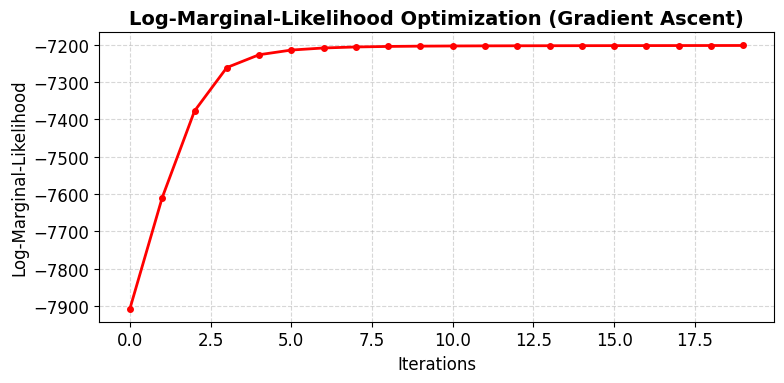

In [21]:
# Plot the Log-Marginal-Likelihood History
plot_lml_history(lml_history)

#### **Phân tích biểu đồ Log-Marginal Likelihood**

- **Xu hướng hội tụ:** Đường cong LML có xu hướng tăng mạnh trong các vòng lặp đầu tiên và bắt đầu bão hòa sau khoảng 10–15 vòng lặp. Điều này cho thấy thuật toán đã tìm thấy một điểm tối ưu cục bộ, tại đó xác suất của dữ liệu huấn luyện được cực đại hóa dựa trên mô hình Gaussian Process đã chọn.

- **Độ ổn định:** Nhờ việc chuẩn hóa biến mục tiêu $y$, giá trị LML biến thiên tương đối mượt mà, không xuất hiện hiện tượng dao động mạnh, nhảy vọt bất thường hoặc lỗi số học như `NaN`. Điều này phản ánh quá trình tối ưu hóa diễn ra ổn định và đáng tin cậy.

- **Kết luận:** Quá trình tối ưu hóa được thực hiện thành công. Bộ tham số kernel thu được giúp mô hình GP khớp dữ liệu tốt, đồng thời hạn chế hiện tượng quá khớp nhờ cơ chế tự điều chỉnh của hàm log-marginal-likelihood.

### **6.3. Visualizing Posterior Predictive and Uncertainty**

Sau khi mô hình đã học được các siêu tham số tối ưu, Gaussian Process cung cấp cho chúng ta một khả năng định lượng sự bất định các mô hình tuyến tính thông thường không có.

Khi dự đoán cho một điểm dữ liệu mới, GPR không chỉ xuất ra một con số, mà nó xuất ra toàn bộ một phân phối chuẩn bao gồm 2 thành phần:

1. **Predictive Mean ($\mu_*$)**: Là đường dự đoán trung bình, đóng vai trò giống như dự đoán điểm của các mô hình hồi quy khác. Nó chính là đường cong tốt nhất tiệm cận với các điểm dữ liệu.
   
2. **Predictive Variance ($\Sigma_*$) & Error Bars:** GPR cung cấp phương sai cho từng điểm dự đoán. Từ phương sai này, ta tính được Độ lệch chuẩn ($\sigma_* = \sqrt{\Sigma_*}$) và vẽ được dải sai số tin cậy 95%** bằng công thức $\mu_* \pm 2\sigma_*$.
   
   **Ý nghĩa:** Vùng dải màu càng hẹp nghĩa là mô hình càng tự tin vào dự đoán của mình, thường là những vùng có dồi dào dữ liệu. Ngược lại, ở những vùng thiếu dữ liệu hoặc có độ nhiễu cao, dải màu sẽ phình to ra, báo hiệu rủi ro sai số lớn.

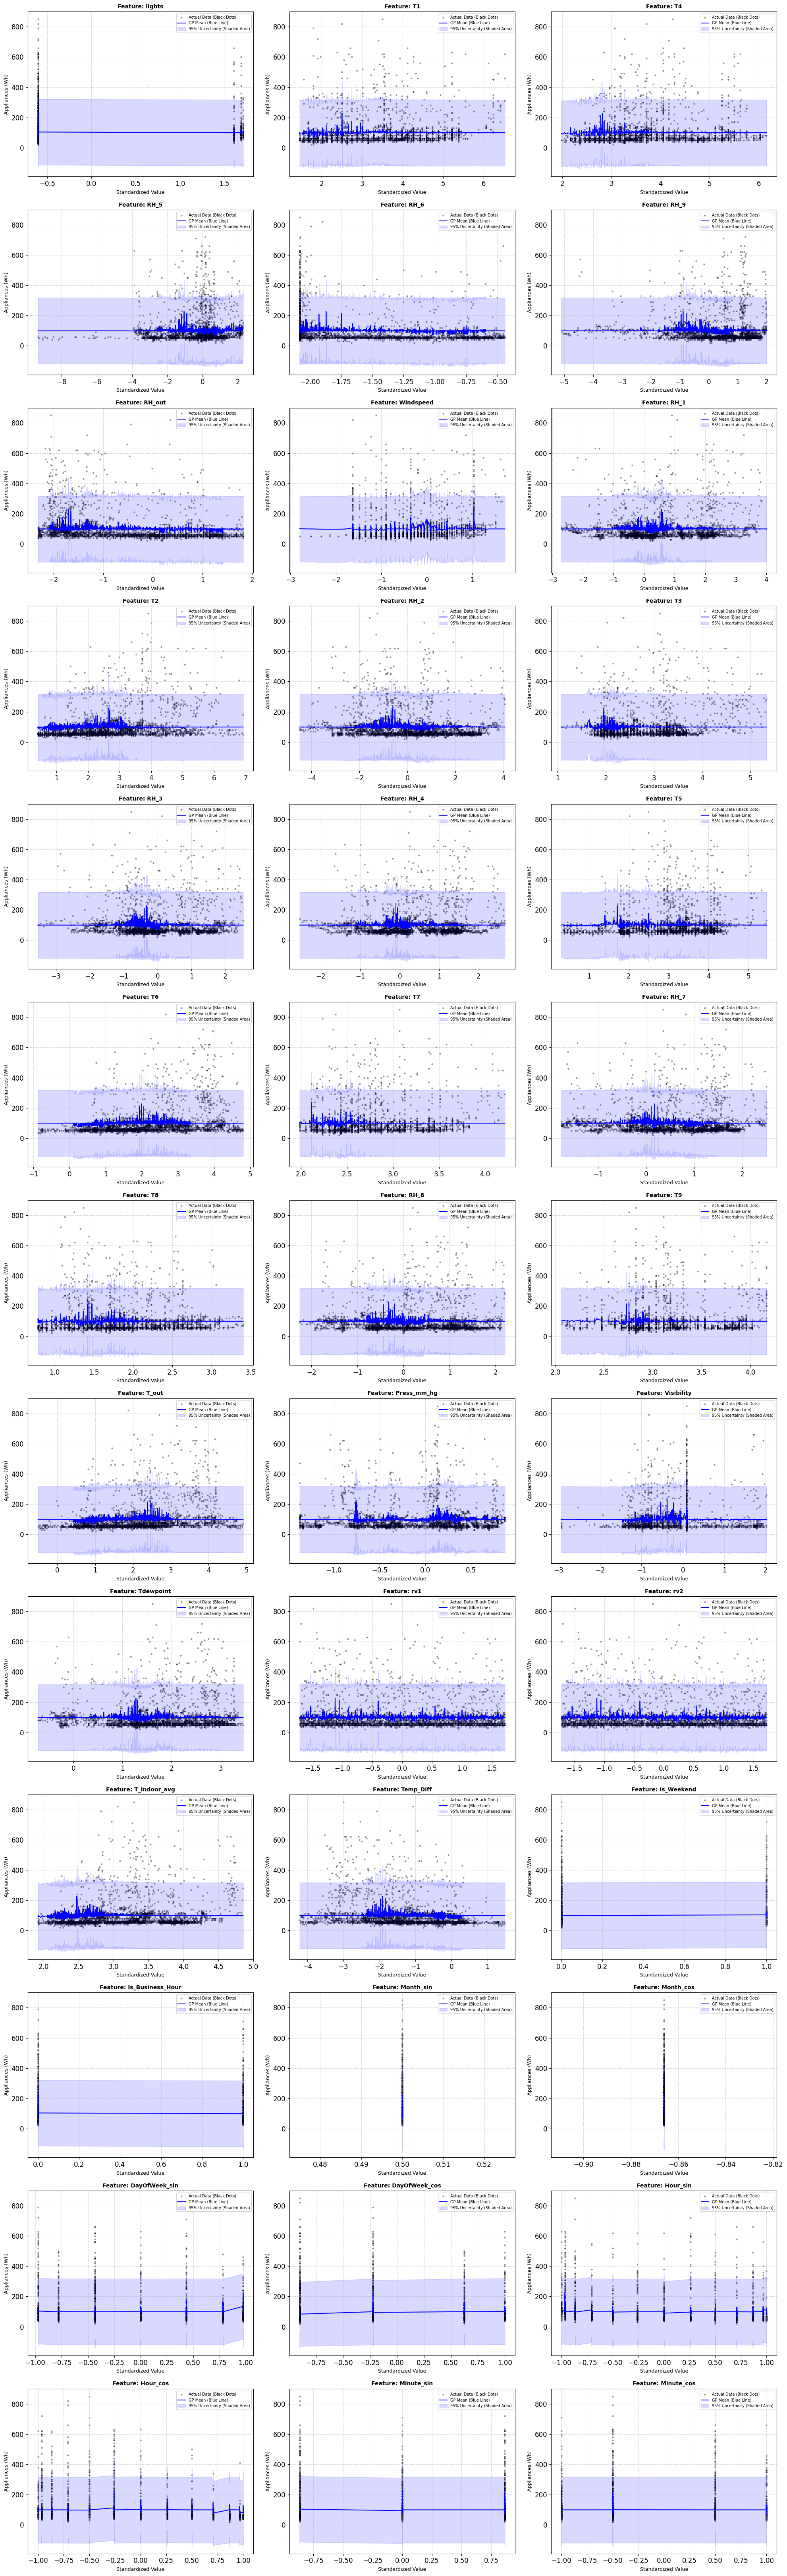

In [22]:
# Plot Posterior Predictive for all features
feature_names = X_train_raw.columns
plot_gp_posterior_predictive(X_te, y_test, mu_gp, std_gp, feature_names)

#### **Phân tích biểu đồ Posterior Predictive của Gaussian Process**

**1. Đường dự báo trung bình (*GP Mean* – đường màu xanh)**

- Đường màu xanh đại diện cho giá trị kỳ vọng mà mô hình Gaussian Process dự đoán.
- Đường này bám theo xu hướng chung của dữ liệu thực tế, cho thấy mô hình đã học được cấu trúc tổng quát của dữ liệu.
- Mô hình không cố gắng đi qua toàn bộ các điểm dữ liệu mà tạo ra một đường cong mượt mà. Điều này chứng tỏ mô hình không chỉ ghi nhớ nhiễu mà đang học được quy luật tổng quát.

**2. Dải bất định (*95% Confidence Interval* – vùng màu xanh nhạt)**

- Vùng màu xanh nhạt biểu diễn khoảng tin cậy 95%, tương ứng với sai số xấp xỉ: $\mu(x) \pm 2\sigma(x)$

- **Nhận xét về độ rộng:** Dải bất định bao phủ phần lớn các điểm dữ liệu thực tế, điều này cho thấy mô hình GP có khả năng ước lượng tốt độ nhiễu và mức độ không chắc chắn của dữ liệu.
- **Ý nghĩa thực tế:** Đối với dữ liệu tiêu thụ điện vốn thường có mức nhiễu cao, dải bất định rộng phản ánh rằng mô hình nhận thức rõ sự khó dự đoán của hệ thống. Điều này giúp người dùng có cái nhìn thận trọng hơn thay vì chỉ dựa vào một giá trị dự báo duy nhất.

**3. Phân bố dữ liệu thực tế (*Actual Data* – các chấm đen)**

- Các điểm dữ liệu thực tế phân tán khá rộng, cho thấy nhiều yếu tố ảnh hưởng đến biến mục tiêu mà một đặc trưng đơn lẻ trên trục X chưa thể giải thích đầy đủ.
- Tuy nhiên, đường dự báo của Gaussian Process vẫn đóng vai trò như một trục xương sống phản ánh xu hướng chính của dữ liệu, đồng thời thể hiện rõ mức độ bất định thông qua vùng tin cậy.


## **7. Robust Regression — Hồi quy Bền vững xử lý Ngoại lai**

**Mục tiêu:** Cài đặt thuật toán hồi quy bền vững (Robust Regression) để giảm ảnh hưởng của các ngoại lai (outliers) lên mô hình hồi quy. Thay vì MSE (dễ bị ảnh hưởng bởi outlier), ta sử dụng **Huber Loss** kết hợp với thuật toán **IRLS (Iteratively Reweighted Least Squares)**.

**Lý thuyết:**
- **OLS (Ordinary Least Squares)** tối thiểu hóa tổng bình phương sai số — rất nhạy cảm với outliers vì bình phương khuếch đại sai số lớn.
- **Huber Loss** kết hợp ưu điểm của cả L2 (MSE) và L1 (MAE): sử dụng L2 cho sai số nhỏ và L1 cho sai số lớn.
- **IRLS** giải bài toán Huber Loss bằng cách lặp đi lặp lại: mỗi vòng lặp tính trọng số cho từng mẫu, sau đó giải bài toán WLS (Weighted Least Squares).

$$\text{Huber Loss: } L_\delta(r) = \begin{cases} \frac{1}{2}r^2 & \text{if } |r| \le \delta \\ \delta|r| - \frac{1}{2}\delta^2 & \text{if } |r| > \delta \end{cases}$$

$$\text{IRLS weight: } w_i = \begin{cases} 1 & \text{if } |r_i| \le \delta \\ \frac{\delta}{|r_i|} & \text{if } |r_i| > \delta \end{cases}$$

### **7.1. Training — Huấn luyện IRLS-Huber trên dữ liệu gốc**

So sánh OLS và IRLS-Huber trên dữ liệu gốc (không outlier nhân tạo) và vẽ đồ thị hội tụ Huber Loss.

Training on original data (no artificial outliers)

[OLS] Test Metrics: {'MSE': 7778.6569089463355, 'RMSE': 88.19669443321749, 'MAE': 59.84694821537185, 'R2': 0.058041864751440464}

--- IRLS-Huber ---
  IRLS hội tụ sau 18 vòng lặp.
[IRLS-Huber] Test Metrics: {'MSE': 7355.4677736399235, 'RMSE': 85.76402377244158, 'MAE': 43.58408806937352, 'R2': 0.10928804431904837}


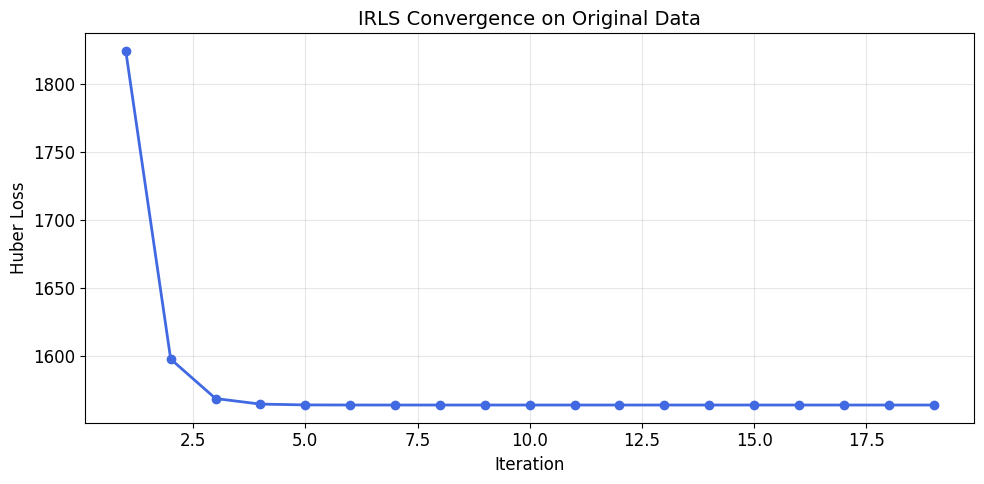

In [23]:
_tmal.start(); _t0 = time.time()
# Train OLS on original data
print("Training on original data (no artificial outliers)")

w_ols_original   = LinearRegression.fit_ols(Phi_train, y_train)
y_pred_ols_test  = LinearRegression.predict(Phi_test, w_ols_original)
metrics_ols_original = LinearRegression.metrics(y_test, y_pred_ols_test)
print(f"\n[OLS] Test Metrics: {metrics_ols_original}")

# Train IRLS-Huber on original data
print("\n--- IRLS-Huber ---")
w_irls_original, loss_hist_original = RobustRegression.fit_irls_huber(
    Phi_train, y_train, delta=50.0, max_iter=100, lam=1.0
)
y_pred_irls_test     = LinearRegression.predict(Phi_test, w_irls_original)
metrics_irls_original = LinearRegression.metrics(y_test, y_pred_irls_test)
print(f"[IRLS-Huber] Test Metrics: {metrics_irls_original}")

# Plot Huber Loss history
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(range(1, len(loss_hist_original) + 1), loss_hist_original, 'o-', color='royalblue', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Huber Loss')
ax.set_title('IRLS Convergence on Original Data')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **7.2. Sensitivity Analysis — Phân tích Độ nhạy với Outliers nhân tạo**

**Phương pháp:**
1. Chèn một tỉ lệ outliers nhân tạo vào tập huấn luyện (thay đổi giá trị `y` của một số mẫu thành giá trị cực lớn).
2. Huấn luyện cả OLS và IRLS-Huber trên dữ liệu bị nhiễm outlier.
3. So sánh hiệu năng trên tập Test (không bị nhiễm) để đánh giá mức độ bền vững.

In [24]:
_tmal.start(); _t0 = time.time()
# Experiment with multiple outlier fractions
outlier_fractions = [0.01, 0.03, 0.05, 0.10, 0.15, 0.20]

results_ols = []
results_irls = []

print("SENSITIVITY ANALYSIS: OLS vs IRLS-Huber under Artificial Outliers")

for frac in outlier_fractions:
    y_train_corrupted, mask = RobustRegression.inject_outliers(y_train, fraction=frac, multiplier=10)
    n_outliers = mask.sum()
    
    print(f"\n--- Outlier fraction = {frac*100:.0f}% ({n_outliers} samples) ---")
    
    # OLS on corrupted data
    w_ols_c      = LinearRegression.fit_ols(Phi_train, y_train_corrupted)
    y_pred_ols_c = LinearRegression.predict(Phi_test, w_ols_c)
    m_ols        = LinearRegression.metrics(y_test, y_pred_ols_c)
    results_ols.append(m_ols)
    print(f"  [OLS]        RMSE = {m_ols['RMSE']:.4f}, MAE = {m_ols['MAE']:.4f}, R² = {m_ols['R2']:.4f}")
    
    # IRLS-Huber on corrupted data
    w_irls_c, _    = RobustRegression.fit_irls_huber(Phi_train, y_train_corrupted, delta=50.0, max_iter=100, lam=1.0)
    y_pred_irls_c  = LinearRegression.predict(Phi_test, w_irls_c)
    m_irls         = LinearRegression.metrics(y_test, y_pred_irls_c)
    results_irls.append(m_irls)
    print(f"  [IRLS-Huber] RMSE = {m_irls['RMSE']:.4f}, MAE = {m_irls['MAE']:.4f}, R² = {m_irls['R2']:.4f}")
_perf_records['Sensitivity Analysis (OLS vs IRLS-Huber)'] = {'time_s': time.time()-_t0, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

SENSITIVITY ANALYSIS: OLS vs IRLS-Huber under Artificial Outliers

--- Outlier fraction = 1% (138 samples) ---
  [OLS]        RMSE = 88.5222, MAE = 59.8812, R² = 0.0511
  IRLS hội tụ sau 19 vòng lặp.
  [IRLS-Huber] RMSE = 85.7577, MAE = 43.8065, R² = 0.1094

--- Outlier fraction = 3% (414 samples) ---
  [OLS]        RMSE = 99.3102, MAE = 81.4929, R² = -0.1943
  IRLS hội tụ sau 19 vòng lặp.
  [IRLS-Huber] RMSE = 85.5450, MAE = 44.8084, R² = 0.1138

--- Outlier fraction = 5% (690 samples) ---
  [OLS]        RMSE = 86.5716, MAE = 52.0150, R² = 0.0924
  IRLS hội tụ sau 18 vòng lặp.
  [IRLS-Huber] RMSE = 85.7591, MAE = 43.3403, R² = 0.1094

--- Outlier fraction = 10% (1381 samples) ---
  [OLS]        RMSE = 94.8483, MAE = 71.4799, R² = -0.0894
  IRLS hội tụ sau 18 vòng lặp.
  [IRLS-Huber] RMSE = 85.5857, MAE = 44.8653, R² = 0.1130

--- Outlier fraction = 15% (2071 samples) ---
  [OLS]        RMSE = 91.7668, MAE = 63.7264, R² = -0.0198
  IRLS hội tụ sau 19 vòng lặp.
  [IRLS-Huber] RMSE = 85.

#### **Trực quan hóa kết quả Sensitivity Analysis**

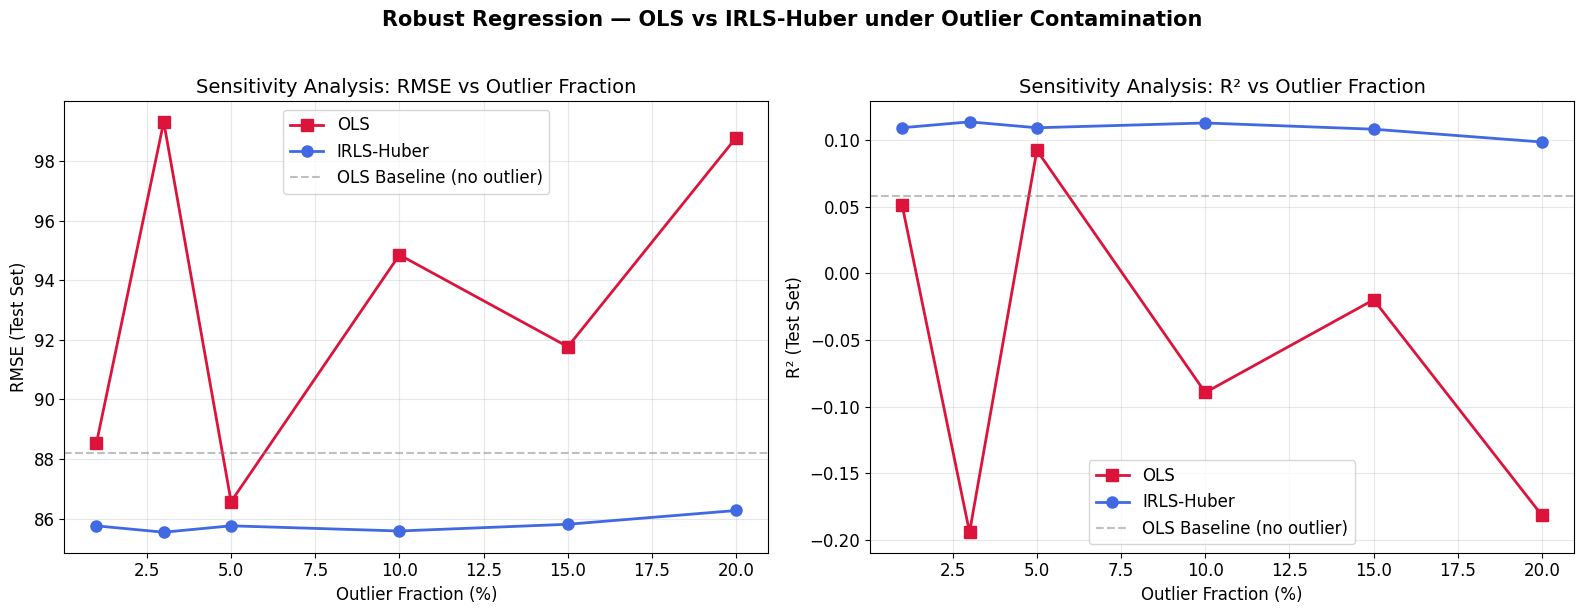


 Outlier % |   OLS RMSE |  IRLS RMSE |     OLS R² |    IRLS R² |  RMSE Diff
--------------------------------------------------------------------------------
        1% |    88.5222 |    85.7577 |     0.0511 |     0.1094 |    +2.7645
        3% |    99.3102 |    85.5450 |    -0.1943 |     0.1138 |   +13.7652
        5% |    86.5716 |    85.7591 |     0.0924 |     0.1094 |    +0.8125
       10% |    94.8483 |    85.5857 |    -0.0894 |     0.1130 |    +9.2626
       15% |    91.7668 |    85.8110 |    -0.0198 |     0.1083 |    +5.9558
       20% |    98.7850 |    86.2732 |    -0.1817 |     0.0987 |   +12.5119

=> IRLS-Huber maintains better performance than OLS as the outlier fraction increases.
=> OLS is heavily affected by outliers due to the squared error amplifying large deviations.


In [25]:
# Trích xuất RMSE và R² để vẽ biểu đồ
rmse_ols = [r['RMSE'] for r in results_ols]
rmse_irls = [r['RMSE'] for r in results_irls]
r2_ols = [r['R2'] for r in results_ols]
r2_irls = [r['R2'] for r in results_irls]
fracs_pct = [f * 100 for f in outlier_fractions]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- RMSE ---
axes[0].plot(fracs_pct, rmse_ols, 's-', color='crimson', linewidth=2, markersize=8, label='OLS')
axes[0].plot(fracs_pct, rmse_irls, 'o-', color='royalblue', linewidth=2, markersize=8, label='IRLS-Huber')
axes[0].axhline(y=metrics_ols_original['RMSE'], color='gray', linestyle='--', alpha=0.5, label='OLS Baseline (no outlier)')
axes[0].set_xlabel('Outlier Fraction (%)')
axes[0].set_ylabel('RMSE (Test Set)')
axes[0].set_title('Sensitivity Analysis: RMSE vs Outlier Fraction')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- R² ---
axes[1].plot(fracs_pct, r2_ols, 's-', color='crimson', linewidth=2, markersize=8, label='OLS')
axes[1].plot(fracs_pct, r2_irls, 'o-', color='royalblue', linewidth=2, markersize=8, label='IRLS-Huber')
axes[1].axhline(y=metrics_ols_original['R2'], color='gray', linestyle='--', alpha=0.5, label='OLS Baseline (no outlier)')
axes[1].set_xlabel('Outlier Fraction (%)')
axes[1].set_ylabel('R² (Test Set)')
axes[1].set_title('Sensitivity Analysis: R² vs Outlier Fraction')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Robust Regression — OLS vs IRLS-Huber under Outlier Contamination', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Detailed comparison table
print("\n" + "=" * 80)
print(f"{'Outlier %':>10} | {'OLS RMSE':>10} | {'IRLS RMSE':>10} | {'OLS R²':>10} | {'IRLS R²':>10} | {'RMSE Diff':>10}")
print("-" * 80)
for i, frac in enumerate(outlier_fractions):
    diff = rmse_ols[i] - rmse_irls[i]
    print(f"{frac*100:>9.0f}% | {rmse_ols[i]:>10.4f} | {rmse_irls[i]:>10.4f} | {r2_ols[i]:>10.4f} | {r2_irls[i]:>10.4f} | {diff:>+10.4f}")
print("=" * 80)

print("\n=> IRLS-Huber maintains better performance than OLS as the outlier fraction increases.")
print("=> OLS is heavily affected by outliers due to the squared error amplifying large deviations.")

### **7.3. Conclusion — Kết luận về Robust Regression**

**Nhận xét:**
- **OLS** rất nhạy cảm với outliers: khi tỉ lệ outlier tăng, RMSE tăng mạnh và R² giảm đáng kể.
- **IRLS-Huber** bền vững hơn nhiều: nhờ cơ chế giảm trọng số cho các mẫu có sai số lớn, mô hình ít bị ảnh hưởng bởi outlier.
- Huber Loss kết hợp ưu điểm của L2 (hiệu quả cho sai số nhỏ) và L1 (bền vững cho sai số lớn).
- Ngưỡng $\delta$ kiểm soát ranh giới giữa vùng L2 và L1 — cần chọn phù hợp với đặc điểm dữ liệu.

---
## **8. Bias-Variance Tradeoff — Phân tích Thực nghiệm**

**Mục tiêu:** Thực nghiệm phân tích sự đánh đổi giữa Bias² và Variance trong mô hình hồi quy thông qua Bootstrapping.

**Lý thuyết:**
- **Mean Squared Error** có thể phân rã thành: $\text{MSE} = \text{Bias}^2 + \text{Variance} + \text{Noise}$
- **Bias²** đo lường sai lệch hệ thống giữa dự đoán trung bình và giá trị thực.
- **Variance** đo lường mức độ dao động của dự đoán khi thay đổi tập huấn luyện.
- **Regularization** (tham số $\lambda$) kiểm soát sự đánh đổi:
  - $\lambda$ nhỏ → Variance cao, Bias thấp (Overfitting)
  - $\lambda$ lớn → Variance thấp, Bias cao (Underfitting)

### **8.1. Bootstrapping (200 iterations) on Training Set**

**Phương pháp:**
1. Tạo 200 tập bootstrap từ tập huấn luyện (sampling with replacement).
2. Với mỗi giá trị $\lambda$ trên Regularization Path, huấn luyện Ridge Regression trên mỗi tập bootstrap.
3. Thu thập tất cả dự đoán trên tập Test.
4. Tính Bias² và Variance từ phân phối dự đoán.

In [26]:
_tmal.start(); _t0 = time.time()
# Thiết lập Regularization Path
lambdas_bv = np.logspace(4, -3, 30)  # 30 giá trị lambda từ 10^4 đến 10^-3
print("BIAS-VARIANCE DECOMPOSITION via Bootstrap (200 iterations)")
print(f"Lambda range: [{lambdas_bv[0]:.2f}, {lambdas_bv[-1]:.6f}]")
print(f"Number of lambdas: {len(lambdas_bv)}")
print(f"Bootstrap iterations: 200")
print()

bias_sq_list, var_list, mse_list = ModelEvaluator.bias_variance_decomposition(
    Phi_train, y_train, Phi_test, y_test,
    lambdas=lambdas_bv, n_bootstrap=200, seed=42
)
_perf_records['Bias-Variance Decomposition (Bootstrap)'] = {'time_s': time.time()-_t0, 'memory_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

BIAS-VARIANCE DECOMPOSITION via Bootstrap (200 iterations)
Lambda range: [10000.00, 0.001000]
Number of lambdas: 30
Bootstrap iterations: 200

  lambda =     0.0010 (log10= -3.00): Bias^2 =  7746.5993, Var =   152.7466, MSE =  7899.3459

Bootstrapping done! Time: 19.0s (200 x 30 lambdas)


### **8.2. Visualization — Bias² & Variance vs Regularization Path**

Trực quan hóa tương quan giữa Bias², Variance và MSE cùng trục với Regularization Path (log₁₀(λ)).

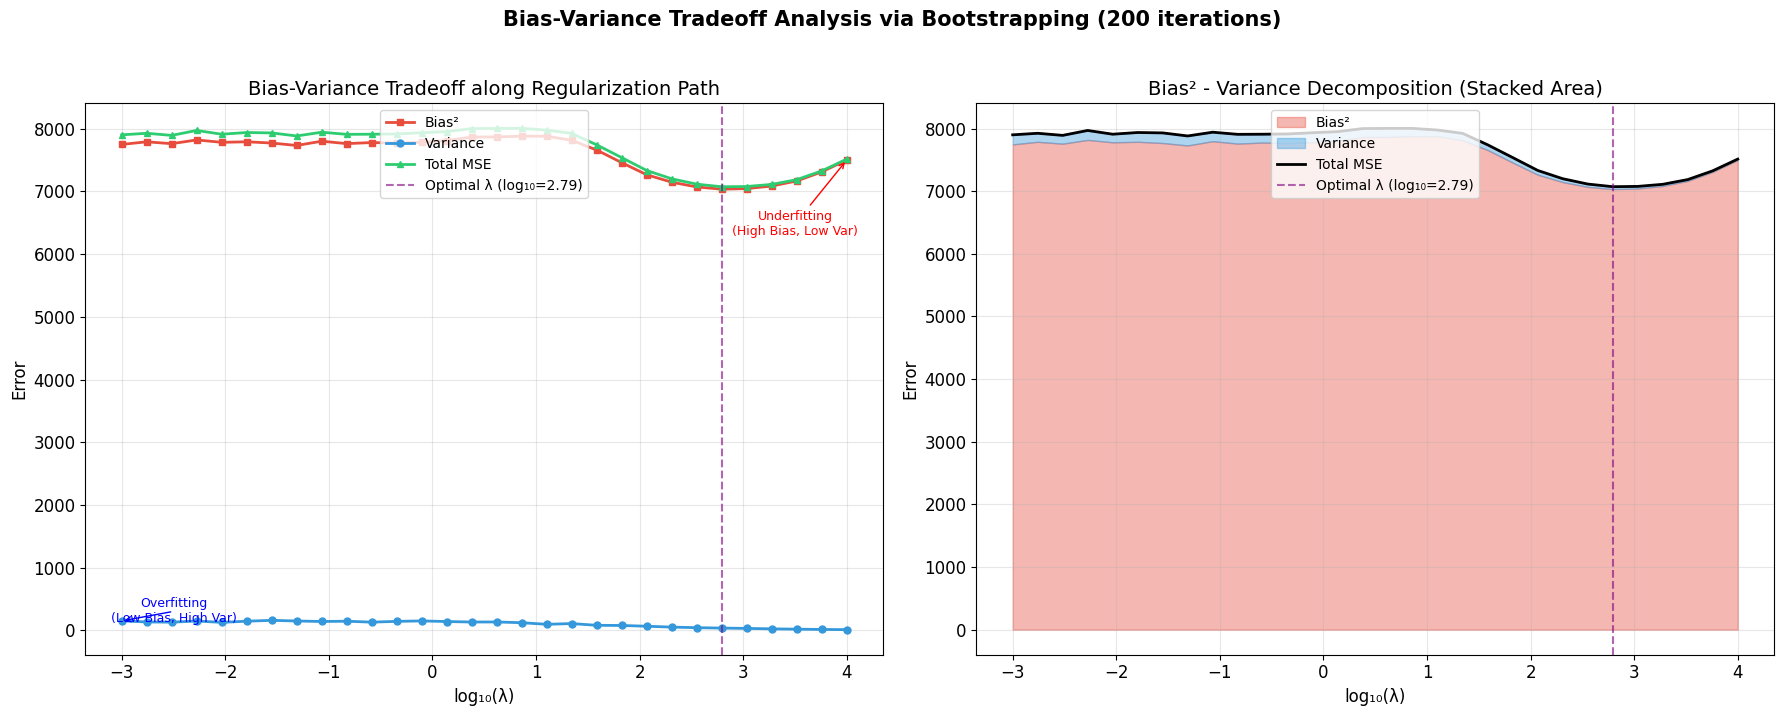


OPTIMAL REGULARIZATION PARAMETER:
  λ* = 621.016942 (log₁₀ = 2.79)
  Bias² = 7033.1707
  Variance = 38.3272
  Total MSE = 7071.4978


In [27]:
log_lambdas = np.log10(lambdas_bv)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ====== Plot 1: Bias², Variance, MSE trên cùng trục ======
ax1 = axes[0]
ax1.plot(log_lambdas, bias_sq_list, 's-', color='#e74c3c', linewidth=2, markersize=5, label='Bias²')
ax1.plot(log_lambdas, var_list, 'o-', color='#3498db', linewidth=2, markersize=5, label='Variance')
ax1.plot(log_lambdas, mse_list, '^-', color='#2ecc71', linewidth=2, markersize=5, label='Total MSE')

# Đánh dấu lambda tối ưu (MSE nhỏ nhất)
best_idx = np.argmin(mse_list)
ax1.axvline(x=log_lambdas[best_idx], color='purple', linestyle='--', alpha=0.6,
            label=f'Optimal λ (log₁₀={log_lambdas[best_idx]:.2f})')

ax1.set_xlabel('log₁₀(λ)')
ax1.set_ylabel('Error')
ax1.set_title('Bias-Variance Tradeoff along Regularization Path')
ax1.legend(loc='upper center', fontsize=10)
ax1.grid(True, alpha=0.3)

# Chú thích vùng Over/Under-fitting
ax1.annotate('Overfitting\n(Low Bias, High Var)', 
             xy=(log_lambdas[-1], var_list[-1]), fontsize=9,
             xytext=(log_lambdas[-1] + 0.5, max(var_list) * 0.8),
             arrowprops=dict(arrowstyle='->', color='blue'),
             color='blue', ha='center')

ax1.annotate('Underfitting\n(High Bias, Low Var)',
             xy=(log_lambdas[0], bias_sq_list[0]), fontsize=9,
             xytext=(log_lambdas[0] - 0.5, max(bias_sq_list) * 0.8),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', ha='center')

# ====== Plot 2: Stacked Area Chart ======
ax2 = axes[1]
ax2.fill_between(log_lambdas, 0, bias_sq_list, alpha=0.4, color='#e74c3c', label='Bias²')
ax2.fill_between(log_lambdas, bias_sq_list, 
                 np.array(bias_sq_list) + np.array(var_list), 
                 alpha=0.4, color='#3498db', label='Variance')
ax2.plot(log_lambdas, mse_list, 'k-', linewidth=2, label='Total MSE')
ax2.axvline(x=log_lambdas[best_idx], color='purple', linestyle='--', alpha=0.6,
            label=f'Optimal λ (log₁₀={log_lambdas[best_idx]:.2f})')

ax2.set_xlabel('log₁₀(λ)')
ax2.set_ylabel('Error')
ax2.set_title('Bias² - Variance Decomposition (Stacked Area)')
ax2.legend(loc='upper center', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Bias-Variance Tradeoff Analysis via Bootstrapping (200 iterations)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# In kết quả tối ưu
print(f"\n{'='*60}")
print(f"OPTIMAL REGULARIZATION PARAMETER:")
print(f"  λ* = {lambdas_bv[best_idx]:.6f} (log₁₀ = {log_lambdas[best_idx]:.2f})")
print(f"  Bias² = {bias_sq_list[best_idx]:.4f}")
print(f"  Variance = {var_list[best_idx]:.4f}")
print(f"  Total MSE = {mse_list[best_idx]:.4f}")
print(f"{'='*60}")

#### **Chi tiết: Bảng Bias²-Variance theo các giá trị Lambda**

In [28]:
# Tạo bảng tổng hợp
print(f"{'log₁₀(λ)':>10} | {'λ':>12} | {'Bias²':>12} | {'Variance':>12} | {'MSE':>12} | {'Bias²/MSE':>10} | {'Var/MSE':>10}")
print("-" * 95)

for i in range(len(lambdas_bv)):
    ratio_bias = bias_sq_list[i] / mse_list[i] * 100
    ratio_var = var_list[i] / mse_list[i] * 100
    marker = " <<<" if i == best_idx else ""
    print(f"{log_lambdas[i]:>10.2f} | {lambdas_bv[i]:>12.4f} | {bias_sq_list[i]:>12.4f} | {var_list[i]:>12.4f} | {mse_list[i]:>12.4f} | {ratio_bias:>9.1f}% | {ratio_var:>9.1f}%{marker}")

  log₁₀(λ) |            λ |        Bias² |     Variance |          MSE |  Bias²/MSE |    Var/MSE
-----------------------------------------------------------------------------------------------
      4.00 |   10000.0000 |    7499.0781 |      13.2077 |    7512.2858 |      99.8% |       0.2%
      3.76 |    5736.1525 |    7308.4425 |      16.5544 |    7324.9968 |      99.8% |       0.2%
      3.52 |    3290.3446 |    7164.1537 |      21.0200 |    7185.1737 |      99.7% |       0.3%
      3.28 |    1887.3918 |    7083.3893 |      26.1940 |    7109.5833 |      99.6% |       0.4%
      3.03 |    1082.6367 |    7042.8834 |      33.1938 |    7076.0772 |      99.5% |       0.5%
      2.79 |     621.0169 |    7033.1707 |      38.3272 |    7071.4978 |      99.5% |       0.5% <<<
      2.55 |     356.2248 |    7068.9618 |      44.7306 |    7113.6924 |      99.4% |       0.6%
      2.31 |     204.3360 |    7144.8559 |      53.8586 |    7198.7145 |      99.3% |       0.7%
      2.07 |     117.2102 |

### **8.3. Conclusion — Kết luận về Bias-Variance Tradeoff**

**Nhận xét từ thực nghiệm:**

1. **Khi λ nhỏ (log₁₀(λ) < 0):**
   - Bias² thấp (mô hình khớp tốt dữ liệu huấn luyện)
   - Variance cao (mô hình thay đổi nhiều khi dữ liệu huấn luyện thay đổi)
   - → Biểu hiện của **Overfitting**

2. **Khi λ lớn (log₁₀(λ) > 2):**
   - Bias² cao (mô hình quá đơn giản, không khớp được dữ liệu)
   - Variance thấp (dự đoán ổn định qua các tập dữ liệu khác nhau)
   - → Biểu hiện của **Underfitting**

3. **Điểm tối ưu:** Tồn tại một giá trị λ* tại đó MSE tổng (Bias² + Variance) đạt cực tiểu — đây là điểm cân bằng tối ưu giữa Bias và Variance.

4. **Ý nghĩa thực tiễn:** Regularization path giúp ta chọn λ phù hợp để mô hình không quá phức tạp (overfitting) cũng không quá đơn giản (underfitting).

---

# **Runtime, Training/Testing & Memory Usage Report**

Phần này tóm tắt thời gian thực thi và mức tiêu thụ bộ nhớ cực đại của từng thuật toán đã được huấn luyện và đánh giá.

- Thời gian thực thi được đo bằng `time.time()` bao quanh từng lệnh huấn luyện/kiểm tra chính.
- Bộ nhớ đỉnh được đo bằng `tracemalloc` (chỉ theo dõi vùng bộ nhớ Python mới cấp phát trong khối đó).



In [ ]:
# Runtime & Memory Usage Report 
rows = []
for _name, _info in _perf_records.items():
    rows.append({
        'Algorithm': _name,
        'Execution Time (s)': round(_info['time_s'], 4),
        'Peak Memory (MB)': round(_info['memory_mb'], 4),
    })

df_perf = pd.DataFrame(rows)

print('RUNTIME AND MEMORY USAGE REPORT')
print(f'Total algorithms tracked : {len(df_perf)}')
if not df_perf.empty:
    print(f'Fastest algorithm        : {df_perf.loc[df_perf["Execution Time (s)"].idxmin(), "Algorithm"]}')
    print(f'Most memory-efficient    : {df_perf.loc[df_perf["Peak Memory (MB)"].idxmin(), "Algorithm"]}')
print()
display(df_perf.style
    .format({'Execution Time (s)': '{:.4f}', 'Peak Memory (MB)': '{:.4f}'})
    .background_gradient(subset=['Execution Time (s)'], cmap='YlOrRd')
    .background_gradient(subset=['Peak Memory (MB)'], cmap='YlGnBu')
    .set_caption('Execution Time and Peak Memory per Algorithm')
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold')]}])
)
